In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

# Loading the computed matrix elements

In [7]:
import pandas as pd

# Path to your final CSV
csv_path = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_1.csv.gz"

# Load ONLY the first 100 rows to save RAM and time
df_head = pd.read_csv(csv_path, nrows=100)

# Show all columns so they don't get hidden with '...'
pd.set_option('display.max_columns', None)

# Display the first 5 events
display(df_head.head())

,Event,x1,x2,s_hat,dynamic_scale,alphas,mg_weight,w_gg,w_uux,w_ddx,w_ssx,w_ccx,w_bbx,ME_Born_SM_Zprime_P0_gg_ttx,ME_Born_NP_Zprime_P0_gg_ttx,ME_Born_Scalar_P0_uux_ttx,ME_Finite_Scalar_P0_uux_ttx,ME_Born_VLF_P0_uux_ttx,ME_Finite_VLF_P0_uux_ttx,ME_Born_Scalar_P2_gg_ttx,ME_Finite_Scalar_P2_gg_ttx,ME_Born_SM_Zprime_P3_ddx_ttx,ME_Born_NP_Zprime_P3_ddx_ttx,ME_Born_SM_Zprime_P2_uux_ttx,ME_Born_NP_Zprime_P2_uux_ttx,ME_Born_VLF_P2_gg_ttx,ME_Finite_VLF_P2_gg_ttx
0,0,0.535321,0.093250,8.436259e+06,215.079138,0.105571,1.266429,0.049457,0.131273,0.043703,-0.003054,-0.000010,0.000004,52.521675,0.0,0.779117,0.002250,0.779117,0.008038,52.520404,-0.002686,0.782617,0.003500,0.782617,0.003500,52.520404,0.002739
1,1,0.149177,0.120458,3.036874e+06,540.747846,0.094969,1.266429,11.384710,3.061229,2.273744,0.119648,0.040342,0.015564,1.626957,0.0,0.523432,0.000560,0.523432,0.000835,1.626951,0.000003,0.523438,0.000006,0.523438,0.000006,1.626951,0.000060
2,2,0.147763,0.115535,2.885135e+06,595.503418,0.093983,1.266429,12.823875,3.360803,2.502814,0.136713,0.046929,0.018322,1.083339,0.0,0.480237,0.000475,0.480237,0.000721,1.083336,0.000007,0.480242,0.000005,0.480242,0.000005,1.083336,0.000045
3,3,0.117550,0.121702,2.417715e+06,309.036718,0.101130,1.266429,24.983392,5.010926,3.913404,0.242747,0.082858,0.030607,5.927869,0.0,0.678654,0.000532,0.678654,0.000823,5.927803,-0.000137,0.678657,0.000003,0.678657,0.000003,5.927803,0.000136
4,4,0.054772,0.245186,2.269555e+06,172.088491,0.108570,1.266429,19.894106,5.899902,3.289666,0.116973,0.050488,0.017131,22.475527,0.0,0.827272,0.000598,0.827272,0.000931,22.474705,-0.000624,0.827275,0.000003,0.827275,0.000003,22.474705,0.000458


In [12]:
print(np.sqrt(2.365224e+06))

1537.9284768805082


In [1]:
import pandas as pd
import numpy as np
import glob

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_PATTERN = "./MatrixElements/Unweighted/*.csv.gz"
OUTPUT_CSV    = "./Likelihoods/Likelihoods_AllModels_Combined_Unweighted.csv.gz"

# Target artificial scale factors for the BSM models
Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P2_uux_ttx", "P3_ddx_ttx", "P0_gg_ttx"]
}

# --- MANUAL CROSS-SECTION INPUTS (in pb) ---
CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# --- LIKELIHOOD BASELINE --- (The denominator for your LLR)
BASELINE_MODEL = "Scalar"

# ==========================================
# 2. LOAD & CONCATENATE ALL SAMPLES
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    print(f"  -> Reading {file_path}...")
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

# Concatenate all loaded dataframes into a single pool
df = pd.concat(dataframes, ignore_index=True)
original_len = len(df)

# Filter out negative weights entirely across the combined pool
df = df[df["mg_weight"] >= 0].reset_index(drop=True)

# Compute the global normalized event weight w_i over the ENTIRE combined dataset
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

print("=" * 60)
print(f"Successfully concatenated {len(csv_files)} files.")
print(f"Loaded total of {original_len} events. Kept {len(df)} events with positive weights.")
print("Computing likelihoods over combined pool...")
print("=" * 60)

# ==========================================
# 3. PASS 1: COMPUTE RAW PROBABILITIES
# ==========================================
for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        # ---------------------------------------------------------
        # FLAVOR SYMMETRY FIX WITH COMPONENT-WISE CLIPPING
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (
                np.clip(df["w_uux"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ddx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ccx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ssx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_bbx"], a_min=0.0, a_max=None)
            )
        else:
            # Clip the single channel flux
            flux = np.clip(df[f"w_{parton_pair}"], a_min=0.0, a_max=None)
            
        # Select the correct column names
        if model == "Zprime":
            if ch == "P2_uux_ttx" or ch == "P3_ddx_ttx":
                sm_col  = "ME_Born_Scalar_P0_uux_ttx" 
            else:
                sm_col  = "ME_Born_Scalar_P2_gg_ttx"
            bsm_col = f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col  = f"ME_Born_{model}_{ch}"
            bsm_col = f"ME_Finite_{model}_{ch}"
            
        # Compute probabilities
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    p_model_total = p_sm_total + (scale_factor * p_bsm_leading)
    
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_Leading_{model}"] = p_bsm_leading
    df[f"P_Total_{model}"] = p_model_total

# ==========================================
# 4. PASS 2: EXACT REWEIGHTING & NORMALIZATION (LLR)
# ==========================================
epsilon = 1e-300  # Safeguard against log(0)

# Define the physical Baseline for the Log-Likelihood Ratios
p_baseline = df[f"P_Total_{BASELINE_MODEL}"]
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]

# SAFEGUARD: Clip baseline probabilities to strictly be >= epsilon
p_baseline_safe = np.clip(p_baseline, a_min=epsilon, a_max=None)

# Precompute the logs for the baseline denominator
log_p_baseline = np.log(p_baseline_safe)
log_p_norm_baseline = np.log(p_baseline_safe / sigma_baseline)

print("\n" + "="*60)
print(f"Baseline Denominator: {BASELINE_MODEL} (y_dm = {Y_DM_CONFIG[BASELINE_MODEL]['y_dm']})")
print(f"Baseline Total Cross-Section: {sigma_baseline:.6e}")
print("="*60)

for model in MODELS.keys():
    p_target = df[f"P_Total_{model}"]
    sigma_target = CROSS_SECTIONS[model]
    
    # SAFEGUARD: Clip target probabilities to strictly be >= epsilon
    p_target_safe = np.clip(p_target, a_min=epsilon, a_max=None)
    
    # LOG-LIKELIHOOD RATIO (TARGET vs BASELINE)
    log_p_target = np.log(p_target_safe)
    log_p_norm_target = np.log(p_target_safe / sigma_target)
    
    llr_unnorm = log_p_target - log_p_baseline
    llr_norm = log_p_norm_target - log_p_norm_baseline
    
    df[f"LLR_Unnorm_{model}"] = llr_unnorm
    df[f"LLR_Norm_{model}"] = llr_norm
    df[f"P_Total_Norm_{model}"] = np.where(sigma_target > 0, p_target / sigma_target, 0)
    
    # NEW: Store the per-event weighted LLR
    df[f"Weighted_LLR_{model}"] = df["w_i"] * llr_norm

# ==========================================
# 5. COMPUTE BASE EXPECTED LLR (PER EVENT)
# ==========================================
print("\n" + "="*60)
print("COMPUTING EXPECTED LLR (PER SINGLE OBSERVED EVENT)")
print("="*60)

for model in MODELS.keys():
    
    # Filter out any lingering NaNs just to be perfectly safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # Calculate the Expected LLR for 1 event by summing the new weighted column
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
        
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (per event) : {llr_1event:.6e}")
    print("-" * 60)

# ==========================================
# 6. SAVE RESULTS
# ==========================================
#df.to_csv(OUTPUT_CSV, index=False, compression='infer')
print(f"\nSuccess! Likelihood dataset saved to: {OUTPUT_CSV}")

Looking for files matching: ./MatrixElements/Unweighted/*.csv.gz
Found 16 files. Loading and concatenating...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_01.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_02.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_03.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_04.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_05.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_06.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_07.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_08.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_09.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_10.csv.gz...
  -> Reading ./MatrixElements/Unweighted/Matrix_AllModels_FF_run_11.csv.gz...
  -> Reading ./MatrixElements/Un

In [6]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():

    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"LLR_Norm_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"LLR_Norm_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -2.149788e+04
  -> Total Log-Likelihood    : -13557198172.72
  -> Asimov Significance     : 164664.50 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -1.304228e+04
  -> Total Log-Likelihood    : -8224844703.00
  -> Asimov Significance     : 128256.34 sigma
------------------------------------------------------------


Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz
Found 16 files. Processing sequentially to save RAM...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_01.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_02.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_03.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_04.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_05.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_06.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_07.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar

Throwing toys (L = 3000 fb^-1): 100%|████| 10000/10000 [06:59<00:00, 23.83it/s]



H0 DISTRIBUTION SUMMARY (Scalar Truth)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
500.0                | 18.98          
1000.0               | 37.79          
3000.0               | 113.95         


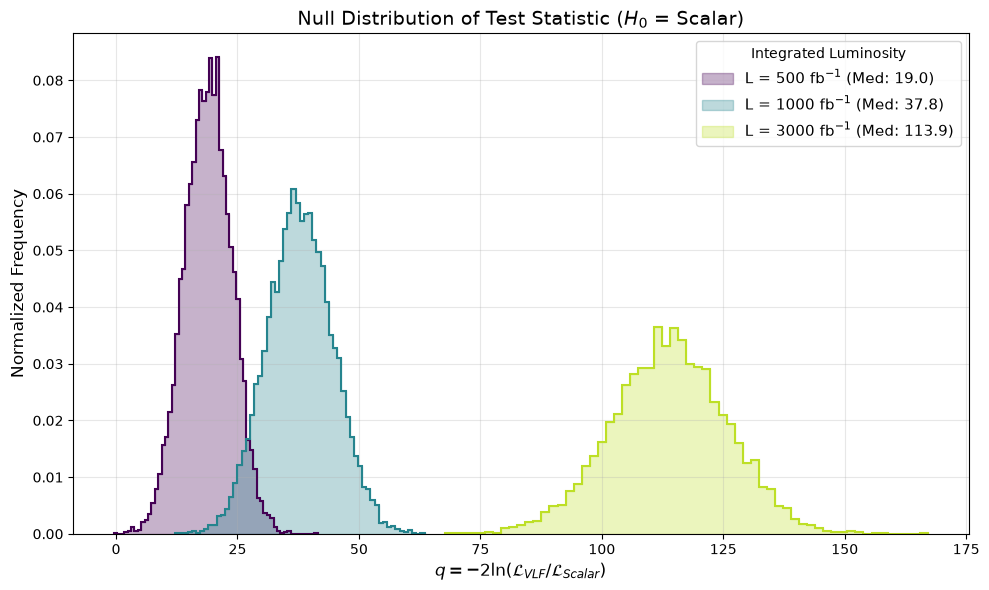

In [1]:
import pandas as pd
import numpy as np
import glob
import sys
import gc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz"

# Define the list of luminosities to scan over (in fb^-1)
LUMI_INV_FB_LIST = [500.0, 1000.0, 3000.0]  
N_TOYS = 10_000

BASELINE_MODEL = "Scalar"
TARGET_MODEL   = "VLF"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2}
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590
}

# ==========================================
# 2. LOAD & COMPUTE DIRECT UNBINNED LLR
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Processing sequentially to save RAM...")

tiny_dataframes = []
total_events = 0
epsilon = 1e-300

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

for file_path in csv_files:
    print(f"  -> Processing {file_path}...")
    df_temp = pd.read_csv(file_path)
    
    total_events += len(df_temp)
    
    # 1. Component-by-Component Flux Clipping
    for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
        if flavor in df_temp.columns:
            df_temp[flavor] = np.clip(df_temp[flavor], a_min=0.0, a_max=None)
            
    flux_q = df_temp["w_uux"] + df_temp["w_ddx"] + df_temp["w_ccx"] + df_temp["w_ssx"] + df_temp["w_bbx"]
    flux_g = df_temp["w_gg"]

    # 2. Compute RAW Differential Cross Sections (No Normalization!)
    # This represents d(sigma)/dx for each event
    P_Total_Scalar = (flux_q * df_temp["ME_Born_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Born_Scalar_P2_gg_ttx"]) + \
                     scale_scalar * (flux_q * df_temp["ME_Finite_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_Scalar_P2_gg_ttx"])
                     
    P_Total_VLF = (flux_q * df_temp["ME_Born_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Born_VLF_P2_gg_ttx"]) + \
                  scale_vlf * (flux_q * df_temp["ME_Finite_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_VLF_P2_gg_ttx"])

    # 3. Calculate Direct Event LLR
    # LLR_event = ln( d(sigma)_targ / d(sigma)_base )
    p_base_safe = np.clip(P_Total_Scalar, a_min=epsilon, a_max=None)
    p_targ_safe = np.clip(P_Total_VLF, a_min=epsilon, a_max=None)
    
    llr_raw_event = np.log(p_targ_safe) - np.log(p_base_safe)
    
    # 4. Extract essential columns and drop heavy arrays
    df_tiny = pd.DataFrame({
        "LLR_Event": llr_raw_event
    })
    
    tiny_dataframes.append(df_tiny)
    del df_temp
    gc.collect()

print("\nConcatenating the optimized arrays...")
df = pd.concat(tiny_dataframes, ignore_index=True)
del tiny_dataframes
gc.collect()

print("\n" + "=" * 60)
print(f"Total Physical Events Retained: {total_events}")
print(f"Base Kinematics: {BASELINE_MODEL} mapped phase space.")
print("=" * 60 + "\n")

# ==========================================
# 3. TOY GENERATOR (DIRECT EXTENDED LIKELIHOOD)
# ==========================================
def throw_toys_h0(df_pool, target_model, baseline_model, lumi_pb, n_toys):
    llr_event_array = df_pool["LLR_Event"].values
    
    sigma_target = CROSS_SECTIONS[target_model]
    sigma_base   = CROSS_SECTIONS[baseline_model]
    
    # Since H0 is true, the expected events are driven by the baseline cross-section
    n_exp_base   = sigma_base * lumi_pb
    n_exp_target = sigma_target * lumi_pb
    
    # The pure Extended Unbinned Likelihood penalty term: -(N_target - N_base)
    # This accounts for the difference in total predicted events without artificial shape/rate splits
    extended_penalty = -(n_exp_target - n_exp_base)
    
    q_values = np.zeros(n_toys)
    
    for i in tqdm(range(n_toys), desc=f"Throwing toys (L = {lumi_pb/1000:.0f} fb^-1)"):
        # Roll the Poisson dice based on the baseline expected yield
        n_obs = np.random.poisson(n_exp_base)
        
        # Sample the raw kinematic coordinates
        sampled_event_llrs = np.random.choice(llr_event_array, size=n_obs, replace=True)
        
        # The true Extended Unbinned LLR is exactly: Sum[ln(dSig_T/dSig_B)] - (N_T - N_B)
        total_llr = np.sum(sampled_event_llrs) + extended_penalty
        
        # The standard test statistic q = -2 * ln(L_targ / L_base)
        q = -2.0 * total_llr
        q_values[i] = q
        
    return q_values

# ==========================================
# 4. RUN PSEUDO-EXPERIMENTS LOOP
# ==========================================
print("GENERATING MONTE CARLO TOYS")
print("="*60)

results_q_H0 = {}
medians = {}

for lumi_fb in LUMI_INV_FB_LIST:
    lumi_pb = lumi_fb * 1000.0
    
    # Run the toys for this specific luminosity
    q_H0 = throw_toys_h0(df, target_model=TARGET_MODEL, 
                         baseline_model=BASELINE_MODEL, lumi_pb=lumi_pb, n_toys=N_TOYS)
    
    # Store the results
    results_q_H0[lumi_fb] = q_H0
    medians[lumi_fb] = np.median(q_H0)

# Print Summary Table
print("\n" + "="*50)
print(f"H0 DISTRIBUTION SUMMARY ({BASELINE_MODEL} Truth)")
print(f"{'Luminosity (fb^-1)':<20} | {'Median q':<15}")
print("-" * 50)
for lumi_fb in LUMI_INV_FB_LIST:
    print(f"{lumi_fb:<20.1f} | {medians[lumi_fb]:<15.2f}")
print("="*50)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))

# Generate distinct colors for each luminosity scan
colors = cm.viridis(np.linspace(0, 0.9, len(LUMI_INV_FB_LIST)))

for (lumi_fb, q_values), color in zip(results_q_H0.items(), colors):
    plt.hist(q_values, bins=60, alpha=0.3, color=color, 
             edgecolor=color, histtype='stepfilled', 
             label=f'L = {lumi_fb:.0f} fb$^{{-1}}$ (Med: {medians[lumi_fb]:.1f})', 
             density=True)
    
    # Add strong outlines to make the overlapping shapes clearer
    plt.hist(q_values, bins=60, color=color, histtype='step', linewidth=1.5, density=True)

plt.title(f'Null Distribution of Test Statistic ($H_0$ = {BASELINE_MODEL})', fontsize=14)
plt.xlabel(r'$q = -2 \ln(\mathcal{L}_{%s} / \mathcal{L}_{%s})$' % (TARGET_MODEL, BASELINE_MODEL), fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.legend(loc='upper right', fontsize=11, title="Integrated Luminosity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import glob
import gc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
from scipy.optimize import minimize

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz"

# Define the list of luminosities to scan over (in fb^-1)
LUMI_INV_FB_LIST = [500.0, 1000.0, 3000.0]  
# Reduced from 10k: Profiling requires minimization per toy, which increases compute time.
N_TOYS = 1000  

BASELINE_MODEL = "Scalar"
TARGET_MODEL   = "VLF"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2}
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590
}

# --- SYSTEMATICS CONFIGURATION ---
# Define the column name that represents the phase space x (squared center-of-mass energy)
KINEMATIC_VAR = "s_hat" 

# Define the anchor points for the theoretical uncertainty grid in invariant mass (GeV)
# Typical top pair production threshold is ~350 GeV
ANCHOR_POINTS = np.linspace(1500.0, 4600.0, 60) 
N_ANCHORS = len(ANCHOR_POINTS)

# Fractional systematic uncertainty size epsilon (e.g., 5%)
SYS_EPSILON = 0.1 

# ==========================================
# 2. HELPER FUNCTIONS FOR SYSTEMATICS
# ==========================================
def compute_W_matrix(x_vals, anchors):
    """
    Computes the piecewise-linear cardinal basis functions W_a(x).
    Returns a matrix of shape (len(x_vals), len(anchors)).
    """
    W = np.zeros((len(x_vals), len(anchors)))
    for a in range(len(anchors)):
        x_a = anchors[a]
        if a == 0:
            x_next = anchors[a+1]
            W[:, a] = np.where(x_vals <= x_a, 1.0, 
                      np.where(x_vals < x_next, (x_next - x_vals)/(x_next - x_a), 0.0))
        elif a == len(anchors) - 1:
            x_prev = anchors[a-1]
            W[:, a] = np.where(x_vals >= x_a, 1.0, 
                      np.where(x_vals > x_prev, (x_vals - x_prev)/(x_a - x_prev), 0.0))
        else:
            x_prev = anchors[a-1]
            x_next = anchors[a+1]
            W[:, a] = np.where((x_vals > x_prev) & (x_vals <= x_a), (x_vals - x_prev)/(x_a - x_prev),
                      np.where((x_vals > x_a) & (x_vals < x_next), (x_next - x_vals)/(x_next - x_a), 0.0))
    return W

def nll_and_grad(theta, N_nom, P_nom, W_matrix, epsilon, I_a):
    """
    Computes the Extended Unbinned NLL and its exact analytical gradient.
    Used by scipy.optimize.minimize to profile the nuisance parameters.
    """
    # 1. Morph the differential shape: (1 + eps * sum(theta_a * W_a(x_i)))
    shape_mod = 1.0 + np.dot(W_matrix, epsilon * theta)
    
    # Protect against extreme unphysical fluctuations pushing PDF < 0
    shape_mod = np.clip(shape_mod, 1e-9, None)
    
    # 2. Analytically update expected yield: N_nom * (1 + eps * sum(theta_a * I_a))
    N_exp = N_nom * (1.0 + np.sum(epsilon * theta * I_a))
    
    # 3. Compute Negative Log-Likelihood
    # -ln L = N_exp - Sum[ln(P_nom * shape_mod)] + 0.5 * Sum(theta^2)
    nll = N_exp - np.sum(np.log(P_nom)) - np.sum(np.log(shape_mod)) + 0.5 * np.sum(theta**2)
    
    # 4. Compute Analytical Gradient (Jacobian)
    # d(NLL)/d(theta_j) = N_nom * eps * I_j - Sum[ eps * W_j(x_i) / shape_mod ] + theta_j
    grad = N_nom * epsilon * I_a - np.dot(W_matrix.T, 1.0 / shape_mod) * epsilon + theta
    
    return nll, grad

# ==========================================
# 3. LOAD & COMPUTE DIRECT UNBINNED POOL
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

tiny_dataframes = []
total_events = 0
epsilon_val = 1e-300

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

print(f"Found {len(csv_files)} files. Processing sequentially to save RAM...")
for file_path in csv_files:
    print(f"  -> Processing {file_path}...")
    df_temp = pd.read_csv(file_path)
    total_events += len(df_temp)
    
    for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
        if flavor in df_temp.columns:
            df_temp[flavor] = np.clip(df_temp[flavor], a_min=0.0, a_max=None)
            
    flux_q = df_temp["w_uux"] + df_temp["w_ddx"] + df_temp["w_ccx"] + df_temp["w_ssx"] + df_temp["w_bbx"]
    flux_g = df_temp["w_gg"]

    P_Total_Scalar = (flux_q * df_temp["ME_Born_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Born_Scalar_P2_gg_ttx"]) + \
                     scale_scalar * (flux_q * df_temp["ME_Finite_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_Scalar_P2_gg_ttx"])
                     
    P_Total_VLF = (flux_q * df_temp["ME_Born_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Born_VLF_P2_gg_ttx"]) + \
                  scale_vlf * (flux_q * df_temp["ME_Finite_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_VLF_P2_gg_ttx"])

    df_tiny = pd.DataFrame({
        "P_Base": np.clip(P_Total_Scalar, a_min=epsilon_val, a_max=None),
        "P_Targ": np.clip(P_Total_VLF, a_min=epsilon_val, a_max=None),
        
        # Take the square root of s_hat to obtain the invariant mass in GeV
        "x": np.sqrt(df_temp[KINEMATIC_VAR]) 
    })
    
    tiny_dataframes.append(df_tiny)
    del df_temp
    gc.collect()

print("\nConcatenating the optimized arrays...")
df = pd.concat(tiny_dataframes, ignore_index=True)
del tiny_dataframes
gc.collect()

# Precompute the global W matrix and Probability-Weighted Integrals (I_a)
print("Precomputing Spline Integrals (I_a) over the phase space...")
W_pool = compute_W_matrix(df["x"].values, ANCHOR_POINTS)

# I_a = (1/Sum(P_nom)) * Sum(P_nom * W_a)
I_a_base = np.average(W_pool, weights=df["P_Base"].values, axis=0)
I_a_targ = np.average(W_pool, weights=df["P_Targ"].values, axis=0)

# Extract flat numpy arrays for fast memory sampling in the toy loop
P_Base_array = df["P_Base"].values
P_Targ_array = df["P_Targ"].values
W_pool_array = W_pool

print("\n" + "=" * 60)
print(f"Total Physical Events Retained: {total_events}")
print(f"Base Kinematics: {BASELINE_MODEL} mapped phase space.")
print("=" * 60 + "\n")

# ==========================================
# 4. TOY GENERATOR WITH PROFILING
# ==========================================
def throw_toys_h0(lumi_pb, n_toys):
    sigma_base = CROSS_SECTIONS[BASELINE_MODEL]
    sigma_targ = CROSS_SECTIONS[TARGET_MODEL]
    
    n_exp_base = sigma_base * lumi_pb
    n_exp_targ = sigma_targ * lumi_pb
    
    q_values = np.zeros(n_toys)
    
    # Bound the nuisance parameters to physically reasonable variations (+/- 5 sigma)
    bounds = [(-5.0, 5.0) for _ in range(N_ANCHORS)]
    
    for i in tqdm(range(n_toys), desc=f"Throwing toys (L = {lumi_pb/1000:.0f} fb^-1)"):
        # Roll actual number of observed events based on H0 truth
        n_obs = np.random.poisson(n_exp_base)
        
        # Sample events' unbinned kinematics uniformly from the H0 pool
        sampled_idx = np.random.choice(len(P_Base_array), size=n_obs, replace=True)
        
        P_base_sample = P_Base_array[sampled_idx]
        P_targ_sample = P_Targ_array[sampled_idx]
        W_sample = W_pool_array[sampled_idx]
        
        # Profile Baseline Hypothesis (Numerator in LLR)
        res_base = minimize(
            nll_and_grad, x0=np.zeros(N_ANCHORS), 
            args=(n_exp_base, P_base_sample, W_sample, SYS_EPSILON, I_a_base),
            method='L-BFGS-B', jac=True, bounds=bounds
        )
        nll_base_min = res_base.fun
        
        # Profile Target Hypothesis (Denominator in LLR)
        res_targ = minimize(
            nll_and_grad, x0=np.zeros(N_ANCHORS), 
            args=(n_exp_targ, P_targ_sample, W_sample, SYS_EPSILON, I_a_targ),
            method='L-BFGS-B', jac=True, bounds=bounds
        )
        nll_targ_min = res_targ.fun
        
        # Test Statistic: q = -2 * ln(L_targ / L_base) = 2 * (NLL_targ - NLL_base)
        q_values[i] = 2.0 * (nll_targ_min - nll_base_min)
        
    return q_values

# ==========================================
# 5. RUN PSEUDO-EXPERIMENTS & VISUALIZATION
# ==========================================
print("\n" + "="*60)
print(f"GENERATING TOYS WITH SYSTEMATICS (Epsilon = {SYS_EPSILON*100}%)")
print("="*60)

results_q_H0 = {}
medians = {}

for lumi_fb in LUMI_INV_FB_LIST:
    q_H0 = throw_toys_h0(lumi_fb * 1000.0, n_toys=N_TOYS)
    results_q_H0[lumi_fb] = q_H0
    medians[lumi_fb] = np.median(q_H0)

# Print Summary Table
print("\n" + "="*50)
print(f"H0 DISTRIBUTION SUMMARY ({BASELINE_MODEL} Truth)")
print(f"{'Luminosity (fb^-1)':<20} | {'Median q':<15}")
print("-" * 50)
for lumi_fb in LUMI_INV_FB_LIST:
    print(f"{lumi_fb:<20.1f} | {medians[lumi_fb]:<15.2f}")
print("="*50)

# Visualization
plt.figure(figsize=(10, 6))
colors = cm.viridis(np.linspace(0, 0.9, len(LUMI_INV_FB_LIST)))

for (lumi_fb, q_values), color in zip(results_q_H0.items(), colors):
    plt.hist(q_values, bins=60, alpha=0.3, color=color, 
             edgecolor=color, histtype='stepfilled', 
             label=f'L = {lumi_fb:.0f} fb$^{{-1}}$ (Med: {medians[lumi_fb]:.1f})', 
             density=True)
    
    # Add strong outlines to make the overlapping shapes clearer
    plt.hist(q_values, bins=60, color=color, histtype='step', linewidth=1.5, density=True)

plt.title(f'Null Distribution with Profiling ($H_0$ = {BASELINE_MODEL})', fontsize=14)
plt.xlabel(r'$q = -2 \ln(\mathcal{L}_{\rm Targ} / \mathcal{L}_{\rm Base})$', fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.legend(loc='upper right', fontsize=11, title="Integrated Luminosity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz
Found 16 files. Processing sequentially to save RAM...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_01.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_02.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_03.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_04.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_05.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_06.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_07.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar

Throwing toys (L = 500 fb^-1):  11%|▊       | 108/1000 [04:57<40:56,  2.75s/it]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import glob
import gc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
from scipy.optimize import minimize
import concurrent.futures
import multiprocessing

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz"

LUMI_INV_FB_LIST = [500.0, 1000.0, 3000.0]  
N_TOYS = 1000  

BASELINE_MODEL = "Scalar"
TARGET_MODEL   = "VLF"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2}
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590
}

# --- SYSTEMATICS CONFIGURATION ---
KINEMATIC_VAR = "s_hat" 
ANCHOR_POINTS = np.linspace(1500.0, 4500.0, 60) 
N_ANCHORS = len(ANCHOR_POINTS)
SYS_EPSILON = 0.10  

# Set up physical bounds for the minimizer (+/- 5 sigma)
BOUNDS = [(-5.0, 5.0) for _ in range(N_ANCHORS)]

# Number of CPU cores to use for parallel processing
N_CORES = max(1, multiprocessing.cpu_count() - 1)

# ==========================================
# 2. HELPER FUNCTIONS FOR SYSTEMATICS
# ==========================================
def compute_W_matrix(x_vals, anchors):
    W = np.zeros((len(x_vals), len(anchors)))
    for a in range(len(anchors)):
        x_a = anchors[a]
        if a == 0:
            x_next = anchors[a+1]
            W[:, a] = np.where(x_vals <= x_a, 1.0, 
                      np.where(x_vals < x_next, (x_next - x_vals)/(x_next - x_a), 0.0))
        elif a == len(anchors) - 1:
            x_prev = anchors[a-1]
            W[:, a] = np.where(x_vals >= x_a, 1.0, 
                      np.where(x_vals > x_prev, (x_vals - x_prev)/(x_a - x_prev), 0.0))
        else:
            x_prev = anchors[a-1]
            x_next = anchors[a+1]
            W[:, a] = np.where((x_vals > x_prev) & (x_vals <= x_a), (x_vals - x_prev)/(x_a - x_prev),
                      np.where((x_vals > x_a) & (x_vals < x_next), (x_next - x_vals)/(x_next - x_a), 0.0))
    return W

def nll_and_grad(theta, N_nom, counts, W_active, epsilon, I_a, const_nll_term):
    """
    Optimized Unbinned NLL operating ONLY on the active events drawn in the toy.
    Array sizes are ~600 elements instead of 16,000,000.
    """
    shape_mod = 1.0 + np.dot(W_active, epsilon * theta)
    shape_mod = np.clip(shape_mod, 1e-9, None)
    
    N_exp = N_nom * (1.0 + np.sum(epsilon * theta * I_a))
    
    nll = N_exp - const_nll_term - np.sum(counts * np.log(shape_mod)) + 0.5 * np.sum(theta**2)
    
    grad = N_nom * epsilon * I_a - np.dot(W_active.T, counts / shape_mod) * epsilon + theta
    
    return nll, grad

# ==========================================
# 3. LOAD & COMPUTE DIRECT UNBINNED POOL
# ==========================================
def load_and_prepare_data():
    print(f"Looking for files matching: {INPUT_PATTERN}")
    csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

    if not csv_files:
        raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

    tiny_dataframes = []
    total_events = 0
    epsilon_val = 1e-300

    scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
    scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

    print(f"Found {len(csv_files)} files. Processing sequentially to save RAM...")
    for file_path in csv_files:
        df_temp = pd.read_csv(file_path)
        total_events += len(df_temp)
        
        for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
            if flavor in df_temp.columns:
                df_temp[flavor] = np.clip(df_temp[flavor], a_min=0.0, a_max=None)
                
        flux_q = df_temp["w_uux"] + df_temp["w_ddx"] + df_temp["w_ccx"] + df_temp["w_ssx"] + df_temp["w_bbx"]
        flux_g = df_temp["w_gg"]

        P_Total_Scalar = (flux_q * df_temp["ME_Born_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Born_Scalar_P2_gg_ttx"]) + \
                         scale_scalar * (flux_q * df_temp["ME_Finite_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_Scalar_P2_gg_ttx"])
                         
        P_Total_VLF = (flux_q * df_temp["ME_Born_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Born_VLF_P2_gg_ttx"]) + \
                      scale_vlf * (flux_q * df_temp["ME_Finite_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_VLF_P2_gg_ttx"])

        df_tiny = pd.DataFrame({
            "P_Base": np.clip(P_Total_Scalar, a_min=epsilon_val, a_max=None),
            "P_Targ": np.clip(P_Total_VLF, a_min=epsilon_val, a_max=None),
            "x": np.sqrt(df_temp[KINEMATIC_VAR]) 
        })
        
        tiny_dataframes.append(df_tiny)
        del df_temp
        gc.collect()

    print("\nConcatenating the optimized arrays...")
    df = pd.concat(tiny_dataframes, ignore_index=True)
    del tiny_dataframes
    gc.collect()

    print("Precomputing Spline Integrals (I_a) over the phase space...")
    W_pool = compute_W_matrix(df["x"].values, ANCHOR_POINTS)
    I_a_base = np.average(W_pool, weights=df["P_Base"].values, axis=0)
    I_a_targ = np.average(W_pool, weights=df["P_Targ"].values, axis=0)

    print("\n" + "=" * 60)
    print(f"Total Physical Events in MC Pool: {total_events}")
    print(f"Parallel cores assigned: {N_CORES}")
    print("=" * 60 + "\n")
    
    return df, W_pool, I_a_base, I_a_targ

# ==========================================
# 4. PARALLEL TOY WORKER FUNCTION
# ==========================================
def run_single_toy(args):
    """
    Isolated worker function designed for ThreadPoolExecutor.
    Uses np.unique to drastically reduce array sizes before minimization.
    """
    n_exp_base, n_exp_targ = args
    
    # Roll actual number of observed events based on H0 truth
    n_obs = np.random.poisson(n_exp_base)
    
    # Sample indices from the massive 16M pool
    sampled_idx = np.random.choice(POOL_SIZE, size=n_obs, replace=True)
    
    # Extract ONLY the unique events that were actually drawn in this toy
    # 'counts' array will now be exactly the size of unique events (~600 elements)
    unique_idx, counts = np.unique(sampled_idx, return_counts=True)
    
    # Slice the global arrays to match only the active events
    W_active = W_pool_array[unique_idx]
    Log_P_Base_active = Log_P_Base_array[unique_idx]
    Log_P_Targ_active = Log_P_Targ_array[unique_idx]
    
    # Precompute the fixed nominal probability sums for this toy
    const_base = np.sum(counts * Log_P_Base_active)
    const_targ = np.sum(counts * Log_P_Targ_active)
    
    # Profile Baseline Hypothesis
    res_base = minimize(
        nll_and_grad, x0=np.zeros(N_ANCHORS), 
        args=(n_exp_base, counts, W_active, SYS_EPSILON, I_a_base_global, const_base),
        method='L-BFGS-B', jac=True, bounds=BOUNDS
    )
    
    # Profile Target Hypothesis
    res_targ = minimize(
        nll_and_grad, x0=np.zeros(N_ANCHORS), 
        args=(n_exp_targ, counts, W_active, SYS_EPSILON, I_a_targ_global, const_targ),
        method='L-BFGS-B', jac=True, bounds=BOUNDS
    )
    
    # Return Test Statistic: q = 2 * (NLL_targ - NLL_base)
    return 2.0 * (res_targ.fun - res_base.fun)

# ==========================================
# 5. RUN PSEUDO-EXPERIMENTS & VISUALIZATION
# ==========================================
if __name__ == '__main__':
    # Load data and compute global arrays
    df_global, W_pool_array, I_a_base_global, I_a_targ_global = load_and_prepare_data()
    
    # Extract flat numpy arrays and pre-compute logs to save operations in the minimizer
    P_Base_array = df_global["P_Base"].values
    P_Targ_array = df_global["P_Targ"].values
    Log_P_Base_array = np.log(P_Base_array)
    Log_P_Targ_array = np.log(P_Targ_array)
    POOL_SIZE = len(P_Base_array)

    print("\n" + "="*60)
    print(f"GENERATING TOYS WITH SYSTEMATICS (Epsilon = {SYS_EPSILON*100}%)")
    print("="*60)

    results_q_H0 = {}
    medians = {}

    sigma_base = CROSS_SECTIONS[BASELINE_MODEL]
    sigma_targ = CROSS_SECTIONS[TARGET_MODEL]

    for lumi_fb in LUMI_INV_FB_LIST:
        lumi_pb = lumi_fb * 1000.0
        n_exp_base = sigma_base * lumi_pb
        n_exp_targ = sigma_targ * lumi_pb
        
        # Package arguments for the worker threads
        toy_args = [(n_exp_base, n_exp_targ) for _ in range(N_TOYS)]
        
        print(f"Throwing toys (L = {lumi_fb:.0f} fb^-1) across {N_CORES} cores...")
        
        q_values = []
        # Execute toys in parallel using ThreadPoolExecutor (safe for Jupyter/IPython)
        with concurrent.futures.ThreadPoolExecutor(max_workers=N_CORES) as executor:
            results = list(tqdm(executor.map(run_single_toy, toy_args), total=N_TOYS))
            q_values = np.array(results)
            
        results_q_H0[lumi_fb] = q_values
        medians[lumi_fb] = np.median(q_values)

    # Print Summary Table
    print("\n" + "="*50)
    print(f"H0 DISTRIBUTION SUMMARY ({BASELINE_MODEL} Truth)")
    print(f"{'Luminosity (fb^-1)':<20} | {'Median q':<15}")
    print("-" * 50)
    for lumi_fb in LUMI_INV_FB_LIST:
        print(f"{lumi_fb:<20.1f} | {medians[lumi_fb]:<15.2f}")
    print("="*50)

    # Visualization
    plt.figure(figsize=(10, 6))
    colors = cm.viridis(np.linspace(0, 0.9, len(LUMI_INV_FB_LIST)))

    for (lumi_fb, q_values), color in zip(results_q_H0.items(), colors):
        plt.hist(q_values, bins=60, alpha=0.3, color=color, 
                 edgecolor=color, histtype='stepfilled', 
                 label=f'L = {lumi_fb:.0f} fb$^{{-1}}$ (Med: {medians[lumi_fb]:.1f})', 
                 density=True)
        
        plt.hist(q_values, bins=60, color=color, histtype='step', linewidth=1.5, density=True)

    plt.title(f'Null Distribution with Profiling ($H_0$ = {BASELINE_MODEL})', fontsize=14)
    plt.xlabel(r'$q = -2 \ln(\mathcal{L}_{\rm Targ} / \mathcal{L}_{\rm Base})$', fontsize=12)
    plt.ylabel('Normalized Frequency', fontsize=12)
    plt.legend(loc='upper right', fontsize=11, title="Integrated Luminosity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz
Found 16 files. Processing sequentially to save RAM...

Concatenating the optimized arrays...
Precomputing Spline Integrals (I_a) over the phase space...

Total Physical Events in MC Pool: 16000000
Parallel cores assigned: 15


GENERATING TOYS WITH SYSTEMATICS (Epsilon = 10.0%)
Throwing toys (L = 500 fb^-1) across 15 cores...


100%|██████████████████████████████████████| 1000/1000 [20:46<00:00,  1.25s/it]


Throwing toys (L = 1000 fb^-1) across 15 cores...


100%|██████████████████████████████████████| 1000/1000 [45:17<00:00,  2.72s/it]


Throwing toys (L = 3000 fb^-1) across 15 cores...


  0%|                                                 | 0/1000 [00:00<?, ?it/s]

In [2]:
print(np.sqrt(19))

4.358898943540674


Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz
Found 16 files. Processing and Profiling Systematics...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_01.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_02.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_03.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_04.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_05.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_06.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_run_07.csv.gz...
  -> Processing /home/vinicius/UnfoldingBSMttba

Toys (L = 100 fb^-1 | eps = 0.0): 100%|█| 10000/10000 [00:12<00:00, 788.44it/s]
Toys (L = 300 fb^-1 | eps = 0.0): 100%|█| 10000/10000 [00:37<00:00, 263.84it/s]
Toys (L = 500 fb^-1 | eps = 0.0): 100%|█| 10000/10000 [01:03<00:00, 156.33it/s]
Toys (L = 1000 fb^-1 | eps = 0.0): 100%|█| 10000/10000 [02:16<00:00, 73.40it/s]
Toys (L = 3000 fb^-1 | eps = 0.0): 100%|█| 10000/10000 [07:26<00:00, 22.40it/s]



--------------------------------------------------
H0 DISTRIBUTION SUMMARY (eps = 0.0)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
100.0                | 3.83           
300.0                | 11.37          
500.0                | 18.90          
1000.0               | 37.77          
3000.0               | 113.73         
--------------------------------------------------


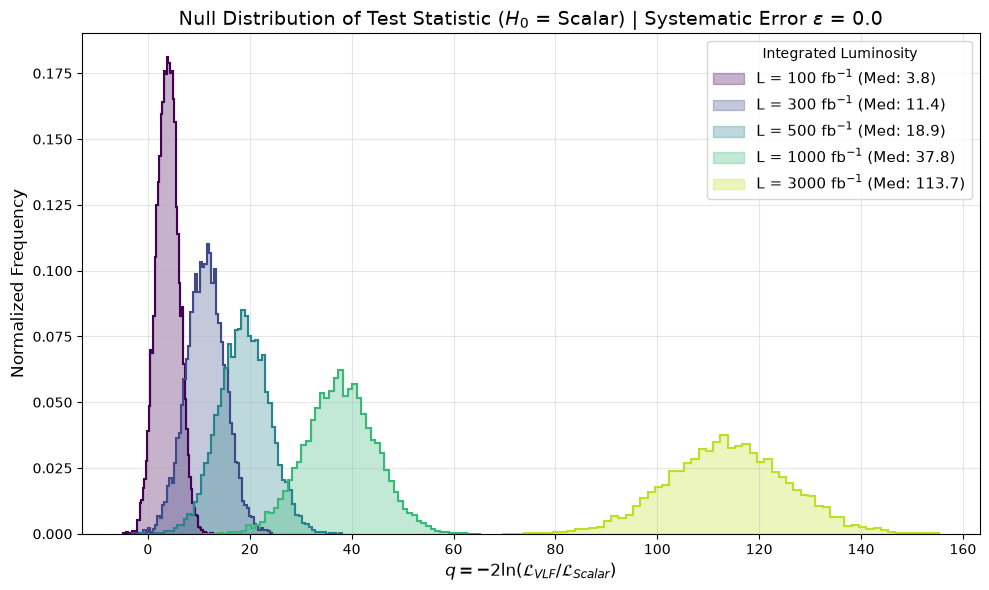


 EVALUATING SYSTEMATIC ERROR: eps = 0.02


Toys (L = 100 fb^-1 | eps = 0.02): 100%|█| 10000/10000 [00:12<00:00, 776.11it/s
Toys (L = 300 fb^-1 | eps = 0.02): 100%|█| 10000/10000 [00:37<00:00, 263.97it/s
Toys (L = 500 fb^-1 | eps = 0.02): 100%|█| 10000/10000 [01:04<00:00, 155.96it/s
Toys (L = 1000 fb^-1 | eps = 0.02): 100%|█| 10000/10000 [02:15<00:00, 73.89it/s
Toys (L = 3000 fb^-1 | eps = 0.02): 100%|█| 10000/10000 [07:19<00:00, 22.74it/s



--------------------------------------------------
H0 DISTRIBUTION SUMMARY (eps = 0.02)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
100.0                | 3.71           
300.0                | 11.00          
500.0                | 18.35          
1000.0               | 36.60          
3000.0               | 110.20         
--------------------------------------------------


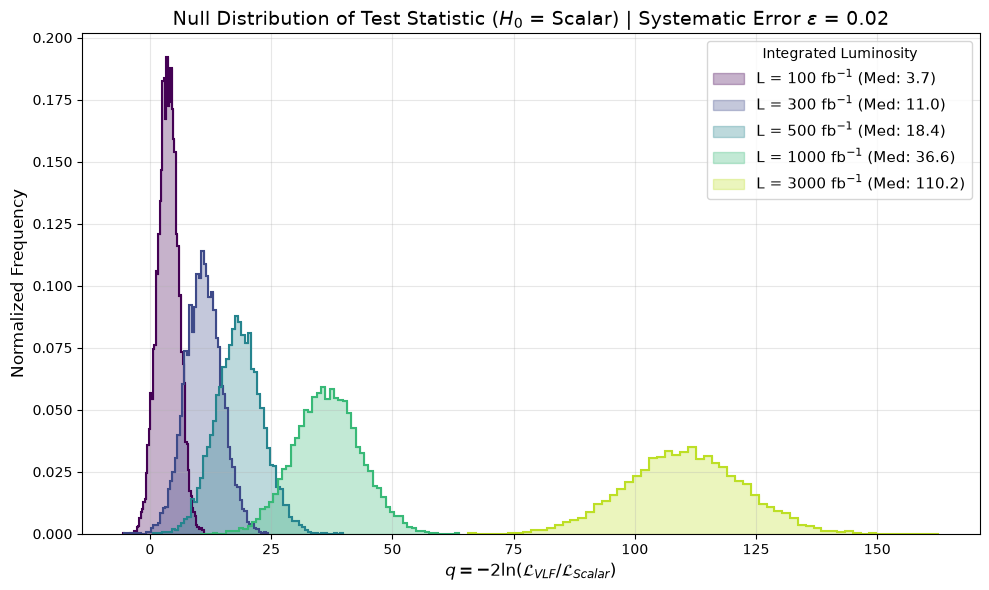


 EVALUATING SYSTEMATIC ERROR: eps = 0.05


Toys (L = 100 fb^-1 | eps = 0.05): 100%|█| 10000/10000 [00:13<00:00, 718.93it/s
Toys (L = 300 fb^-1 | eps = 0.05): 100%|█| 10000/10000 [00:44<00:00, 222.44it/s
Toys (L = 500 fb^-1 | eps = 0.05): 100%|█| 10000/10000 [01:19<00:00, 126.45it/s
Toys (L = 1000 fb^-1 | eps = 0.05): 100%|█| 10000/10000 [02:42<00:00, 61.43it/s
Toys (L = 3000 fb^-1 | eps = 0.05): 100%|█| 10000/10000 [07:44<00:00, 21.51it/s



--------------------------------------------------
H0 DISTRIBUTION SUMMARY (eps = 0.05)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
100.0                | 3.06           
300.0                | 9.14           
500.0                | 15.39          
1000.0               | 30.81          
3000.0               | 91.97          
--------------------------------------------------


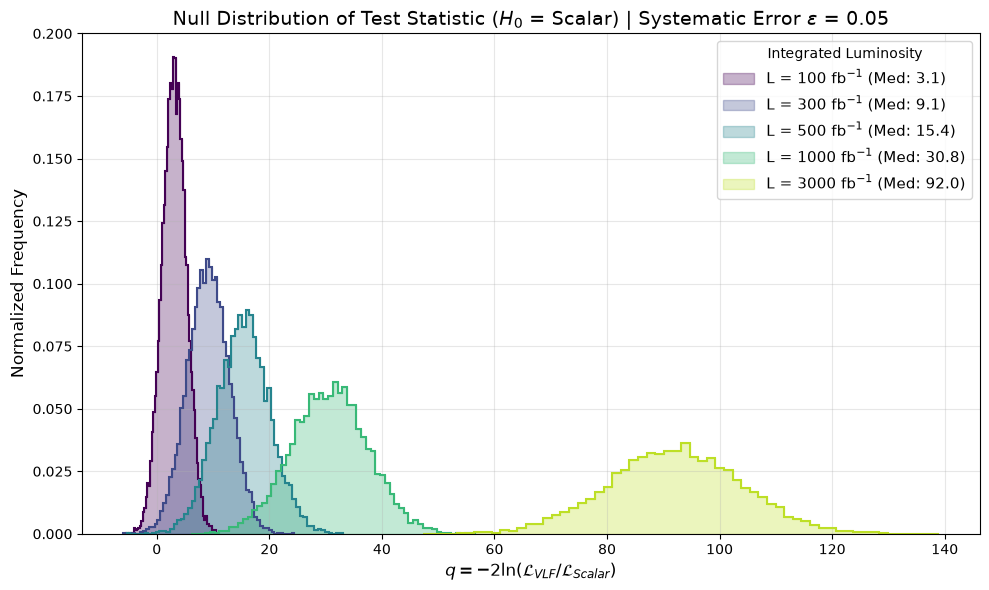


 EVALUATING SYSTEMATIC ERROR: eps = 0.1


Toys (L = 100 fb^-1 | eps = 0.1): 100%|█| 10000/10000 [00:12<00:00, 813.40it/s]
Toys (L = 300 fb^-1 | eps = 0.1): 100%|█| 10000/10000 [00:37<00:00, 269.48it/s]
Toys (L = 500 fb^-1 | eps = 0.1): 100%|█| 10000/10000 [01:02<00:00, 159.64it/s]
Toys (L = 1000 fb^-1 | eps = 0.1): 100%|█| 10000/10000 [02:12<00:00, 75.26it/s]
Toys (L = 3000 fb^-1 | eps = 0.1): 100%|█| 10000/10000 [07:06<00:00, 23.42it/s]



--------------------------------------------------
H0 DISTRIBUTION SUMMARY (eps = 0.1)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
100.0                | 0.97           
300.0                | 2.83           
500.0                | 4.72           
1000.0               | 9.60           
3000.0               | 28.73          
--------------------------------------------------


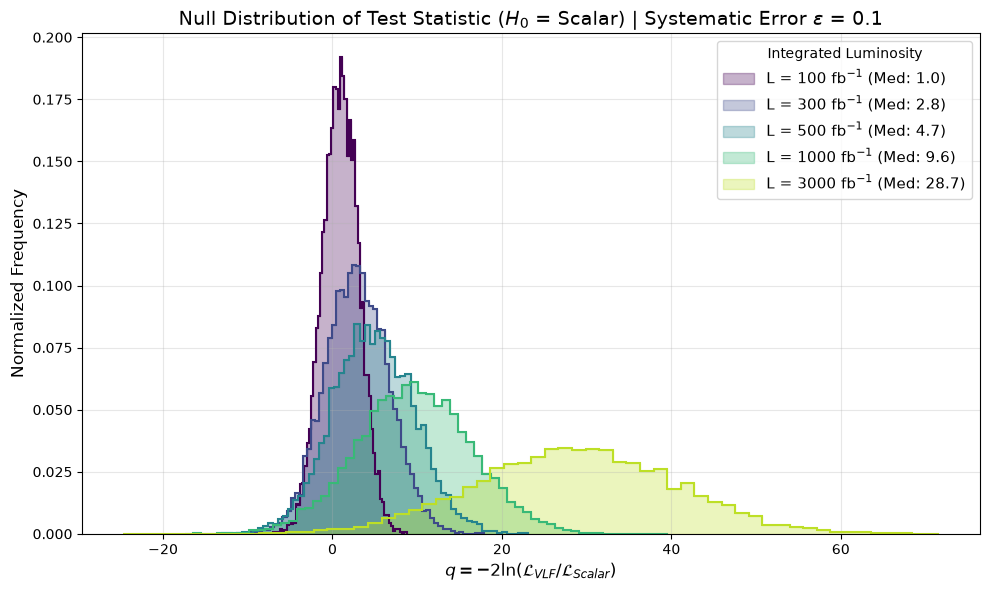


 EVALUATING SYSTEMATIC ERROR: eps = 0.3


Toys (L = 100 fb^-1 | eps = 0.3): 100%|█| 10000/10000 [00:12<00:00, 820.13it/s]
Toys (L = 300 fb^-1 | eps = 0.3): 100%|█| 10000/10000 [00:37<00:00, 267.93it/s]
Toys (L = 500 fb^-1 | eps = 0.3): 100%|█| 10000/10000 [01:03<00:00, 158.31it/s]
Toys (L = 1000 fb^-1 | eps = 0.3): 100%|█| 10000/10000 [02:15<00:00, 73.72it/s]
Toys (L = 3000 fb^-1 | eps = 0.3): 100%|█| 10000/10000 [07:15<00:00, 22.95it/s]



--------------------------------------------------
H0 DISTRIBUTION SUMMARY (eps = 0.3)
Luminosity (fb^-1)   | Median q       
--------------------------------------------------
100.0                | -18.39         
300.0                | -55.22         
500.0                | -91.94         
1000.0               | -184.03        
3000.0               | -551.97        
--------------------------------------------------


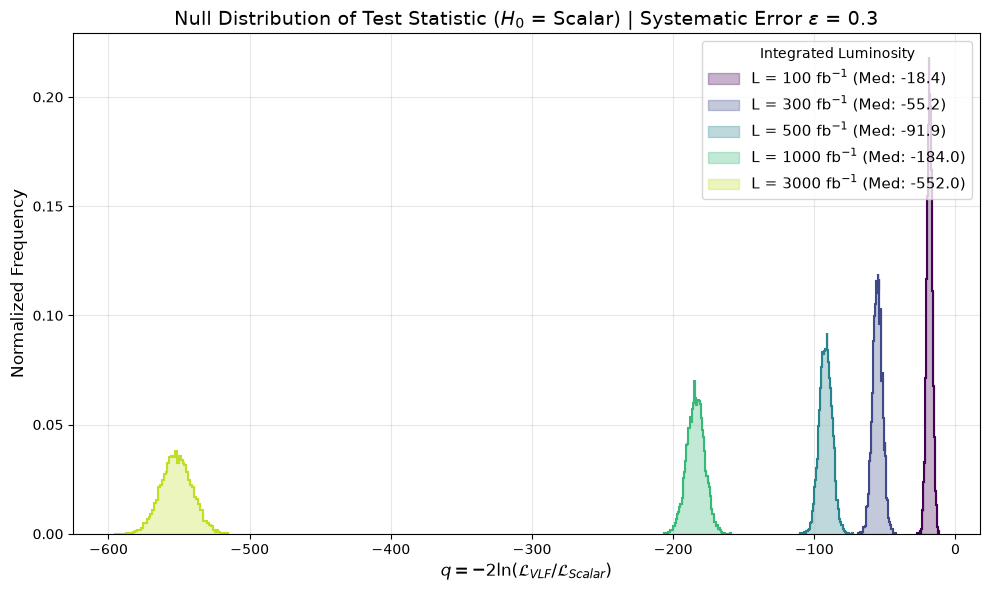

In [5]:
import pandas as pd
import numpy as np
import glob
import sys
import gc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz"

# Scan Parameters
LUMI_INV_FB_LIST = [100.0, 300.0, 500.0, 1000.0, 3000.0]  
SYS_ERRORS = [0.0, 0.02, 0.05, 0.1, 0.3]
N_TOYS = 10_000

BASELINE_MODEL = "Scalar"
TARGET_MODEL   = "VLF"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2}
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590
}

# ==========================================
# 2. LOAD, PROFILE, AND CONDENSE
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Processing and Profiling Systematics...")

tiny_dataframes = []
total_events = 0
epsilon = 1e-300

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

for file_path in csv_files:
    print(f"  -> Processing {file_path}...")
    df_temp = pd.read_csv(file_path)
    
    total_events += len(df_temp)
    
    # 1. Component-by-Component Flux Clipping
    for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
        if flavor in df_temp.columns:
            df_temp[flavor] = np.clip(df_temp[flavor], a_min=0.0, a_max=None)
            
    flux_q = df_temp["w_uux"] + df_temp["w_ddx"] + df_temp["w_ccx"] + df_temp["w_ssx"] + df_temp["w_bbx"]
    flux_g = df_temp["w_gg"]

    # 2. Compute Base Matrix Elements
    P_SM_Base_Scalar = flux_q * df_temp["ME_Born_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Born_Scalar_P2_gg_ttx"]
    P_BSM_Scaled_Scalar = scale_scalar * (flux_q * df_temp["ME_Finite_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_Scalar_P2_gg_ttx"])
    
    P_SM_Base_VLF = flux_q * df_temp["ME_Born_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Born_VLF_P2_gg_ttx"]
    P_BSM_Scaled_VLF = scale_vlf * (flux_q * df_temp["ME_Finite_VLF_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_VLF_P2_gg_ttx"])

    # 3. Profile Theta for each Systematic Error Epsilon
    df_tiny_dict = {}
    
    for eps in SYS_ERRORS:
        # Profile Baseline (Scalar)
        A_base = P_SM_Base_Scalar * eps
        B_base = P_SM_Base_Scalar + P_BSM_Scaled_Scalar
        theta_base = np.where(A_base > 1e-12, (-B_base + np.sqrt(B_base**2 + 4 * A_base**2)) / (2 * A_base), 0.0)
        p_prof_base = B_base + (A_base * theta_base)
        penalty_base = 0.5 * (theta_base ** 2)
        
        # Profile Target (VLF)
        A_targ = P_SM_Base_VLF * eps
        B_targ = P_SM_Base_VLF + P_BSM_Scaled_VLF
        theta_targ = np.where(A_targ > 1e-12, (-B_targ + np.sqrt(B_targ**2 + 4 * A_targ**2)) / (2 * A_targ), 0.0)
        p_prof_targ = B_targ + (A_targ * theta_targ)
        penalty_targ = 0.5 * (theta_targ ** 2)
        
        # Log-Likelihood Ratio
        p_base_safe = np.clip(p_prof_base, a_min=epsilon, a_max=None)
        p_targ_safe = np.clip(p_prof_targ, a_min=epsilon, a_max=None)
        
        log_p_base = np.log(p_base_safe / CROSS_SECTIONS["Scalar"]) - penalty_base
        log_p_targ = np.log(p_targ_safe / CROSS_SECTIONS["VLF"]) - penalty_targ
        
        df_tiny_dict[f"LLR_Norm_eps_{eps}"] = log_p_targ - log_p_base
    
    # 4. Extract profiled columns and drop heavy arrays
    df_tiny = pd.DataFrame(df_tiny_dict)
    tiny_dataframes.append(df_tiny)
    del df_temp
    gc.collect()

print("\nConcatenating the optimized arrays...")
df = pd.concat(tiny_dataframes, ignore_index=True)
del tiny_dataframes
gc.collect()

print("\n" + "=" * 60)
print(f"Total Physical Events Retained: {total_events}")
print(f"Base Kinematics: {BASELINE_MODEL} mapped phase space.")
print("=" * 60 + "\n")

# ==========================================
# 3. TOY GENERATOR 
# ==========================================
def throw_toys_h0(df_pool, eps, target_model, baseline_model, lumi_pb, n_toys):
    # Fetch the dynamically profiled LLR for the current epsilon
    llr_shape_array = df_pool[f"LLR_Norm_eps_{eps}"].values
    
    sigma_target = CROSS_SECTIONS[target_model]
    sigma_base   = CROSS_SECTIONS[baseline_model]
    
    n_exp_base   = sigma_base * lumi_pb
    n_exp_target = sigma_target * lumi_pb
    
    q_values = np.zeros(n_toys)
    
    for i in tqdm(range(n_toys), desc=f"Toys (L = {lumi_pb/1000:.0f} fb^-1 | eps = {eps})"):
        n_obs = np.random.poisson(n_exp_base)
        
        sampled_shape_llrs = np.random.choice(llr_shape_array, size=n_obs, replace=True)
        shape_llr_sum = np.sum(sampled_shape_llrs)
        
        rate_llr = n_obs * np.log(n_exp_target / n_exp_base) - (n_exp_target - n_exp_base)
        q = -2.0 * (rate_llr + shape_llr_sum)
        q_values[i] = q
        
    return q_values

# ==========================================
# 4. RUN SYSTEMATIC LOOPS & PLOTTING
# ==========================================
print("GENERATING MONTE CARLO TOYS OVER SYSTEMATICS")
print("="*60)

for eps in SYS_ERRORS:
    print(f"\n========================================================")
    print(f" EVALUATING SYSTEMATIC ERROR: eps = {eps}")
    print(f"========================================================")
    
    results_q_H0 = {}
    medians = {}
    
    # --- A. Throw Toys for each Luminosity ---
    for lumi_fb in LUMI_INV_FB_LIST:
        lumi_pb = lumi_fb * 1000.0
        q_H0 = throw_toys_h0(df, eps, target_model=TARGET_MODEL, 
                             baseline_model=BASELINE_MODEL, lumi_pb=lumi_pb, n_toys=N_TOYS)
        
        results_q_H0[lumi_fb] = q_H0
        medians[lumi_fb] = np.median(q_H0)

    # --- B. Print Summary for this Epsilon ---
    print(f"\n{'-'*50}")
    print(f"H0 DISTRIBUTION SUMMARY (eps = {eps})")
    print(f"{'Luminosity (fb^-1)':<20} | {'Median q':<15}")
    print("-" * 50)
    for lumi_fb in LUMI_INV_FB_LIST:
        print(f"{lumi_fb:<20.1f} | {medians[lumi_fb]:<15.2f}")
    print("-" * 50)

    # --- C. Generate Plot for this Epsilon ---
    plt.figure(figsize=(10, 6))
    colors = cm.viridis(np.linspace(0, 0.9, len(LUMI_INV_FB_LIST)))

    for (lumi_fb, q_values), color in zip(results_q_H0.items(), colors):
        plt.hist(q_values, bins=60, alpha=0.3, color=color, 
                 edgecolor=color, histtype='stepfilled', 
                 label=f'L = {lumi_fb:.0f} fb$^{{-1}}$ (Med: {medians[lumi_fb]:.1f})', 
                 density=True)
        
        plt.hist(q_values, bins=60, color=color, histtype='step', linewidth=1.5, density=True)

    plt.title(f'Null Distribution of Test Statistic ($H_0$ = {BASELINE_MODEL}) | Systematic Error $\\varepsilon$ = {eps}', fontsize=14)
    plt.xlabel(r'$q = -2 \ln(\mathcal{L}_{%s} / \mathcal{L}_{%s})$' % (TARGET_MODEL, BASELINE_MODEL), fontsize=12)
    plt.ylabel('Normalized Frequency', fontsize=12)
    plt.legend(loc='upper right', fontsize=11, title="Integrated Luminosity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import glob
import sys
import gc
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_*.csv.gz"

# Scan Parameters
LUMI_INV_FB_LIST = [100.0, 300.0, 500.0, 1000.0, 3000.0]  
SYS_ERRORS = [0.0, 0.02, 0.05, 0.1, 0.3]
N_TOYS = 10_000

BASELINE_MODEL = "Scalar"
TARGET_MODEL   = "Zprime"

Y_DM_CONFIG = {
    "Zprime": {"y_dm": 1.0,      "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2}
}

CROSS_SECTIONS = {
    "Zprime": 1.2571816,  
    "Scalar": 1.2612590
}

# ==========================================
# 2. LOAD, PROFILE, AND CONDENSE
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Processing and Profiling Systematics...")

tiny_dataframes = []
total_events = 0
epsilon = 1e-300

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

for file_path in csv_files:
    print(f"  -> Processing {file_path}...")
    df_temp = pd.read_csv(file_path)
    
    total_events += len(df_temp)
    
    # 1. Component-by-Component Flux Clipping
    for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
        if flavor in df_temp.columns:
            df_temp[flavor] = np.clip(df_temp[flavor], a_min=0.0, a_max=None)
            
    # Symmetric flux for Scalar
    flux_q = df_temp["w_uux"] + df_temp["w_ddx"] + df_temp["w_ccx"] + df_temp["w_ssx"] + df_temp["w_bbx"]
    flux_g = df_temp["w_gg"]

    # 2. Compute Base Matrix Elements
    # Baseline (Scalar) uses symmetric quark sums and finite interference terms
    P_SM_Base_Scalar = flux_q * df_temp["ME_Born_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Born_Scalar_P2_gg_ttx"]
    P_BSM_Scaled_Scalar = scale_scalar * (flux_q * df_temp["ME_Finite_Scalar_P0_uux_ttx"] + flux_g * df_temp["ME_Finite_Scalar_P2_gg_ttx"])
    
    # Target (Zprime) uses explicit uux and ddx fluxes for SM and NP Born terms
    P_SM_Base_Zprime = (
        df_temp["w_uux"] * df_temp["ME_Born_SM_Zprime_P2_uux_ttx"] + 
        df_temp["w_ddx"] * df_temp["ME_Born_SM_Zprime_P3_ddx_ttx"] + 
        flux_g * df_temp["ME_Born_SM_Zprime_P0_gg_ttx"]
    )
    
    P_BSM_Scaled_Zprime = scale_zprime * (
        df_temp["w_uux"] * df_temp["ME_Born_NP_Zprime_P2_uux_ttx"] + 
        df_temp["w_ddx"] * df_temp["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
        flux_g * df_temp["ME_Born_NP_Zprime_P0_gg_ttx"]
    )

    # 3. Profile Theta for each Systematic Error Epsilon
    df_tiny_dict = {}
    
    for eps in SYS_ERRORS:
        # Profile Baseline (Scalar)
        A_base = P_SM_Base_Scalar * eps
        B_base = P_SM_Base_Scalar + P_BSM_Scaled_Scalar
        theta_base = np.where(A_base > 1e-12, (-B_base + np.sqrt(B_base**2 + 4 * A_base**2)) / (2 * A_base), 0.0)
        p_prof_base = B_base + (A_base * theta_base)
        penalty_base = 0.5 * (theta_base ** 2)
        
        # Profile Target (Zprime)
        A_targ = P_SM_Base_Zprime * eps
        B_targ = P_SM_Base_Zprime + P_BSM_Scaled_Zprime
        theta_targ = np.where(A_targ > 1e-12, (-B_targ + np.sqrt(B_targ**2 + 4 * A_targ**2)) / (2 * A_targ), 0.0)
        p_prof_targ = B_targ + (A_targ * theta_targ)
        penalty_targ = 0.5 * (theta_targ ** 2)
        
        # Log-Likelihood Ratio
        p_base_safe = np.clip(p_prof_base, a_min=epsilon, a_max=None)
        p_targ_safe = np.clip(p_prof_targ, a_min=epsilon, a_max=None)
        
        log_p_base = np.log(p_base_safe / CROSS_SECTIONS["Scalar"]) - penalty_base
        log_p_targ = np.log(p_targ_safe / CROSS_SECTIONS["Zprime"]) - penalty_targ
        
        df_tiny_dict[f"LLR_Norm_eps_{eps}"] = log_p_targ - log_p_base
    
    # 4. Extract profiled columns and drop heavy arrays
    df_tiny = pd.DataFrame(df_tiny_dict)
    tiny_dataframes.append(df_tiny)
    del df_temp
    gc.collect()

print("\nConcatenating the optimized arrays...")
df = pd.concat(tiny_dataframes, ignore_index=True)
del tiny_dataframes
gc.collect()

print("\n" + "=" * 60)
print(f"Total Physical Events Retained: {total_events}")
print(f"Base Kinematics: {BASELINE_MODEL} mapped phase space.")
print("=" * 60 + "\n")

# ==========================================
# 3. TOY GENERATOR 
# ==========================================
def throw_toys_h0(df_pool, eps, target_model, baseline_model, lumi_pb, n_toys):
    # Fetch the dynamically profiled LLR for the current epsilon
    llr_shape_array = df_pool[f"LLR_Norm_eps_{eps}"].values
    
    sigma_target = CROSS_SECTIONS[target_model]
    sigma_base   = CROSS_SECTIONS[baseline_model]
    
    n_exp_base   = sigma_base * lumi_pb
    n_exp_target = sigma_target * lumi_pb
    
    q_values = np.zeros(n_toys)
    
    for i in tqdm(range(n_toys), desc=f"Toys (L = {lumi_pb/1000:.0f} fb^-1 | eps = {eps})"):
        n_obs = np.random.poisson(n_exp_base)
        
        sampled_shape_llrs = np.random.choice(llr_shape_array, size=n_obs, replace=True)
        shape_llr_sum = np.sum(sampled_shape_llrs)
        
        rate_llr = n_obs * np.log(n_exp_target / n_exp_base) - (n_exp_target - n_exp_base)
        q = -2.0 * (rate_llr + shape_llr_sum)
        q_values[i] = q
        
    return q_values

# ==========================================
# 4. RUN SYSTEMATIC LOOPS & PLOTTING
# ==========================================
print("GENERATING MONTE CARLO TOYS OVER SYSTEMATICS")
print("="*60)

for eps in SYS_ERRORS:
    print(f"\n========================================================")
    print(f" EVALUATING SYSTEMATIC ERROR: eps = {eps}")
    print(f"========================================================")
    
    results_q_H0 = {}
    medians = {}
    
    # --- A. Throw Toys for each Luminosity ---
    for lumi_fb in LUMI_INV_FB_LIST:
        lumi_pb = lumi_fb * 1000.0
        q_H0 = throw_toys_h0(df, eps, target_model=TARGET_MODEL, 
                             baseline_model=BASELINE_MODEL, lumi_pb=lumi_pb, n_toys=N_TOYS)
        
        results_q_H0[lumi_fb] = q_H0
        medians[lumi_fb] = np.median(q_H0)

    # --- B. Print Summary for this Epsilon ---
    print(f"\n{'-'*50}")
    print(f"H0 DISTRIBUTION SUMMARY (eps = {eps})")
    print(f"{'Luminosity (fb^-1)':<20} | {'Median q':<15}")
    print("-" * 50)
    for lumi_fb in LUMI_INV_FB_LIST:
        print(f"{lumi_fb:<20.1f} | {medians[lumi_fb]:<15.2f}")
    print("-" * 50)

    # --- C. Generate Plot for this Epsilon ---
    plt.figure(figsize=(10, 6))
    colors = cm.viridis(np.linspace(0, 0.9, len(LUMI_INV_FB_LIST)))

    for (lumi_fb, q_values), color in zip(results_q_H0.items(), colors):
        plt.hist(q_values, bins=60, alpha=0.3, color=color, 
                 edgecolor=color, histtype='stepfilled', 
                 label=f'L = {lumi_fb:.0f} fb$^{{-1}}$ (Med: {medians[lumi_fb]:.1f})', 
                 density=True)
        
        plt.hist(q_values, bins=60, color=color, histtype='step', linewidth=1.5, density=True)

    plt.title(f'Null Distribution of Test Statistic ($H_0$ = {BASELINE_MODEL} vs $H_1$ = {TARGET_MODEL}) | $\\varepsilon$ = {eps}', fontsize=14)
    plt.xlabel(r'$q = -2 \ln(\mathcal{L}_{%s} / \mathcal{L}_{%s})$' % (TARGET_MODEL, BASELINE_MODEL), fontsize=12)
    plt.ylabel('Normalized Frequency', fontsize=12)
    plt.legend(loc='upper right', fontsize=11, title="Integrated Luminosity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Loading toy distributions from ./Likelihoods/Toy_Joint_LLRs.csv...
VLF Model:
  -> Median q: 3333.33
  -> 1-Sigma Band: [1963.62, 4741.08]
  -> Median Significance: 57.73 sigma

Zprime Model:
  -> Median q: 5941.89
  -> 1-Sigma Band: [3544.30, 7306.98]
  -> Median Significance: 77.08 sigma

Plot saved as Toy_LLR_Distributions.pdf


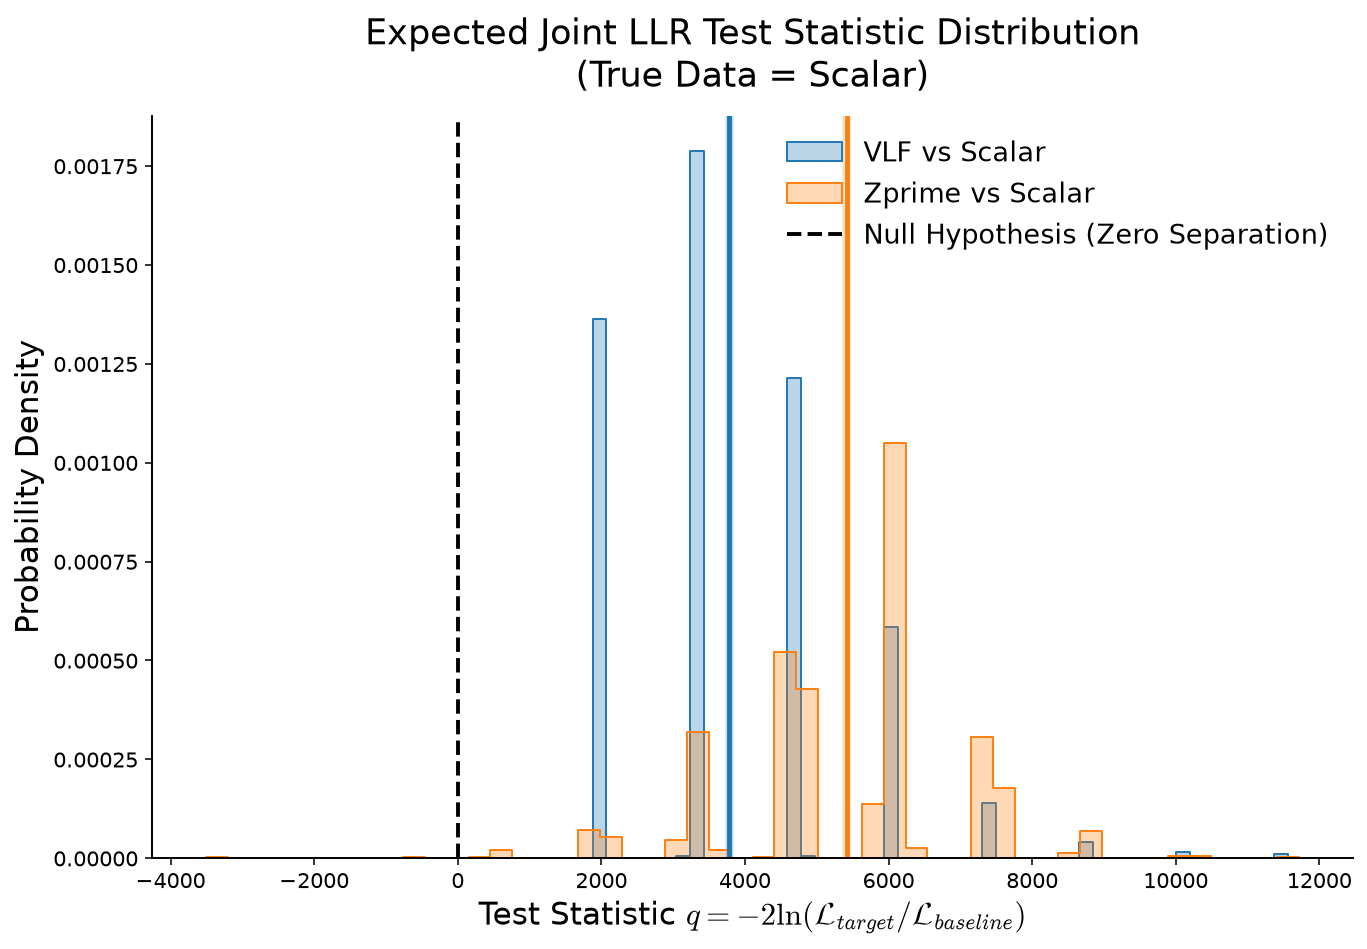

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "./Likelihoods/Toy_Joint_LLRs.csv"
BASELINE_MODEL = "Scalar"

# Visual settings
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "figure.figsize": (10, 7)
})

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading toy distributions from {INPUT_CSV}...")
df_toys = pd.read_csv(INPUT_CSV)

TARGET_MODELS = df_toys.columns.tolist()

# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots()

# Colors for different models
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, model in enumerate(TARGET_MODELS):
    color = colors[idx % len(colors)]
    
    # Extract the data
    data = df_toys[model].values
    
    # Compute the Test Statistic: q = -2 * Joint LLR
    # We do this because -2*LLR follows a chi-square-like distribution 
    # and directly relates to standard deviations (Z = sqrt(q))
    q_data = -2 * data
    
    # Calculate quantiles for the Brazil bands
    median_q = np.percentile(q_data, 50)
    q_1sig_dn = np.percentile(q_data, 16) # -1 sigma
    q_1sig_up = np.percentile(q_data, 84) # +1 sigma

    mean_q = np.mean(q_data)
    unc_q = np.std(q_data, ddof=1)/np.sqrt(len(q_data))
    # Plot the histogram (step filled for HEP style)
    sns.histplot(
        q_data, 
        bins=50, 
        color=color, 
        alpha=0.3, 
        element="step", 
        stat="density",
        label=f"{model} vs {BASELINE_MODEL}",
        ax=ax
    )
    
    # Draw the Median line
    ax.axvline(mean_q, color=color, linestyle="-", linewidth=2.5)
    
    # Draw the +/- 1 Sigma uncertainty bands
    ax.axvspan(mean_q-unc_q, mean_q + unc_q, color=color, alpha=0.15)
    
    print(f"{model} Model:")
    print(f"  -> Median q: {median_q:.2f}")
    print(f"  -> 1-Sigma Band: [{q_1sig_dn:.2f}, {q_1sig_up:.2f}]")
    print(f"  -> Median Significance: {np.sqrt(max(0, median_q)):.2f} sigma\n")

# ==========================================
# 4. FORMATTING
# ==========================================
# Draw the null hypothesis expectation (q = 0)
ax.axvline(0, color="black", linestyle="--", linewidth=2, label="Null Hypothesis (Zero Separation)")

ax.set_title(f"Expected Joint LLR Test Statistic Distribution\n(True Data = {BASELINE_MODEL})", pad=15)
ax.set_xlabel(r"Test Statistic $q = -2 \ln(\mathcal{L}_{target} / \mathcal{L}_{baseline})$")
ax.set_ylabel("Probability Density")

# Remove top and right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper right", frameon=False)
plt.tight_layout()

# Save and show
plt.savefig("Toy_LLR_Distributions.pdf", dpi=300)
print("Plot saved as Toy_LLR_Distributions.pdf")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_AllModels_Combined.csv.gz"

# Luminosity settings
LUMI_FB = 500.0                # Integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0     # Converted to pb^-1 to match cross-section units

N_TOYS = 1000                  # Number of pseudo-experiments to run

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
# We exclude the baseline model from the test list because comparing the baseline 
# to itself mathematically yields an LLR of exactly 0 for every event.
TARGET_MODELS = ["VLF", "Zprime"]

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading likelihood database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)

# Extract the selection probabilities (which is mg_weight / sum(mg_weight))
# We convert to a NumPy array right away to dramatically speed up the sampling loop
probabilities = df["w_i"].values 
pool_size = len(df)

print(f"Loaded pool of {pool_size} events.")

# ==========================================
# 3. TOY MONTE CARLO LOOP
# ==========================================
# Dictionary to store the arrays of joint LLRs for each model
toy_results = {}

for model in TARGET_MODELS:
    print("\n" + "="*60)
    print(f"GENERATING TOYS: {model} vs {BASELINE_MODEL}")
    print("="*60)
    
    # Extract the unweighted LLR values for this specific model comparison
    # We use LLR_Norm so that the cross-section normalization is correctly accounted for
    single_llrs = df[f"LLR_Norm_{model}"].values
    
    # 1. Compute the expected number of events (Mean of the Poisson distribution)
    # We use the BASELINE cross-section because we are assuming the Baseline (Scalar) 
    # is the TRUE physical reality that is generating the data.
    N_expected = CROSS_SECTIONS[BASELINE_MODEL] * LUMI_PB
    
    print(f"Target Luminosity : {LUMI_FB} fb^-1")
    print(f"Expected Yield    : {N_expected:.1f} events")
    
    # 2. Draw N_TOYS values from a Poisson distribution
    # This array represents the total number of observed events in each of our fake universes
    n_obs_array = np.random.poisson(lam=N_expected, size=N_TOYS)
    
    # Array to store the final Joint LLR for each toy
    joint_llrs = np.zeros(N_TOYS)
    
    print(f"Running {N_TOYS} pseudo-experiments (this may take a moment)...")
    
    for i in range(N_TOYS):
        # The number of events observed in this specific toy
        n_obs = n_obs_array[i]
        
        # 3 & 4. Select 'n_obs' events from the unweighted LLR array.
        # We sample WITH replacement (replace=True) using the MC weights as the probabilities.
        # np.random.choice returns the INDICES of the chosen events.
        selected_indices = np.random.choice(
            a=pool_size, 
            size=n_obs, 
            replace=True, 
            p=probabilities
        )
        
        # 5. Compute the Joint LLR by summing the single-event LLRs of the selected events
        joint_llrs[i] = np.sum(single_llrs[selected_indices])
        
        # Optional: Print progress every 250 toys
        if (i + 1) % 250 == 0:
            print(f"  -> Finished {i + 1} / {N_TOYS} toys")
            
    # Store the final array of joint LLRs in our results dictionary
    toy_results[model] = joint_llrs
    
    # Quick statistical summary of the generated distribution
    median_llr = np.median(joint_llrs)
    print("-" * 60)
    print(f"Median Joint LLR for {model}: {median_llr:.2f}")

# ==========================================
# 4. SAVE TOY RESULTS (Optional)
# ==========================================
# If you want to plot these distributions later, it is good practice to save them
# so you don't have to rerun the random sampling every time you tweak a matplotlib setting.
df_toys = pd.DataFrame(toy_results)
df_toys.to_csv("Toy_Joint_LLRs.csv", index=False)
print("\nToy distributions saved to Toy_Joint_LLRs.csv")

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_swapFix.csv.gz...
Loaded 1000000 events. Kept 1000000 events with strictly positive weights.
Computing likelihoods...


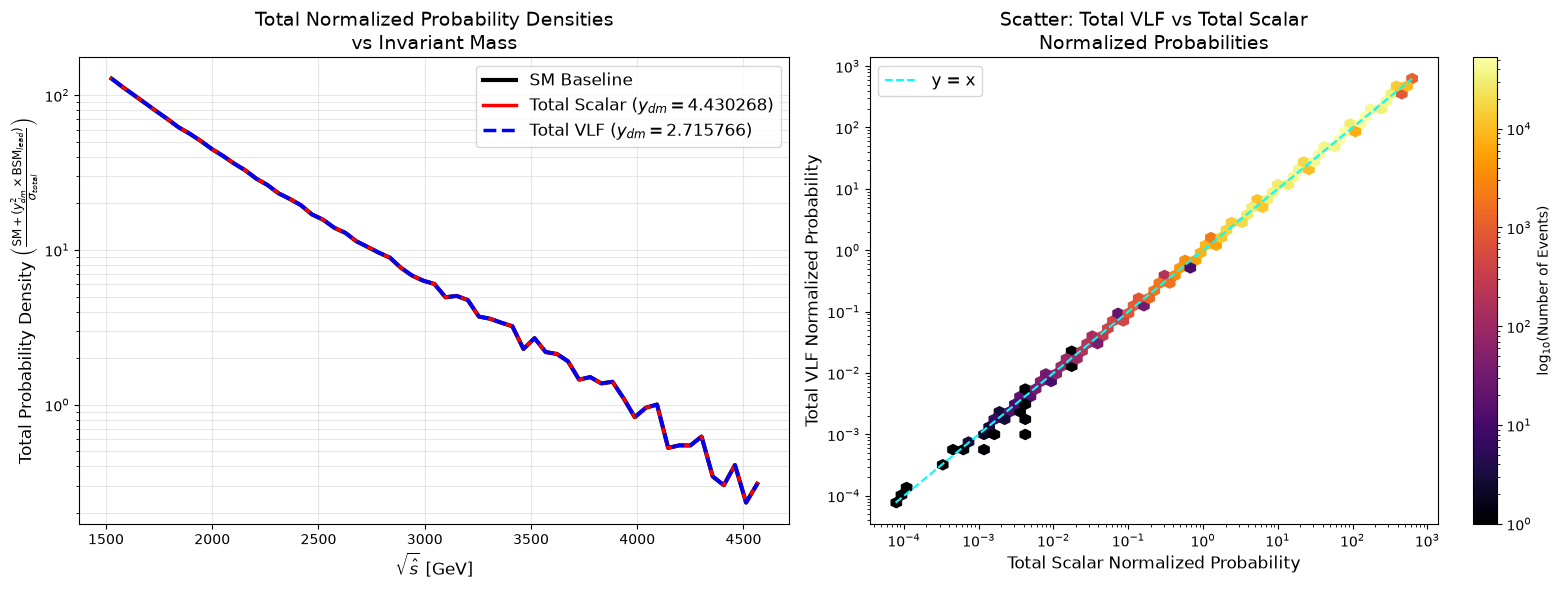


GENERATING DIAGNOSTIC PLOT: PYTHON VS LHE TRUTH


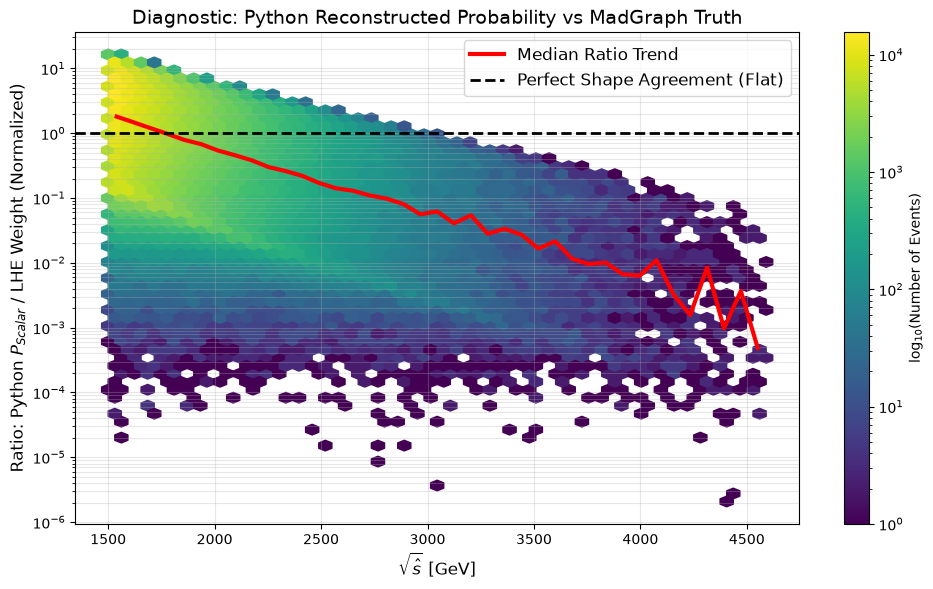

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_swapFix.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

CROSS_SECTIONS = {
    "VLF":    1.2612590,#1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
original_len = len(df)


print(f"Loaded {original_len} events. Kept {len(df)} events with strictly positive weights.")
print("Computing likelihoods...")

# ==========================================
# 3. COMPUTE TOTAL NORMALIZED CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Apply the flavor symmetry sum for the quark initial states
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# 1. Pure SM Background (using Scalar Born as reference)
df["SM_Only_Unnorm"] = (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + (flux_g * df["ME_Born_VLF_P2_gg_ttx"])
df["Norm_Prob_SM"] = df["SM_Only_Unnorm"] / CROSS_SECTIONS["Scalar"]

# 2. Total Scalar Model (SM Born + Scalar Finite) / Sigma_Total
df["Total_Prob_Scalar"] = (
    (flux_q * df["ME_Born_Scalar_P0_uux_ttx"]) + 
        (flux_g * df["ME_Born_Scalar_P2_gg_ttx"]) 
    +
    scale_scalar * (
        (flux_q * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
        (flux_g * df["ME_Finite_Scalar_P2_gg_ttx"])
    )
) / CROSS_SECTIONS["Scalar"]

# 3. Total VLF Model (VLF Born + VLF Finite) / Sigma_Total
# Note: Re-calculating the Born part using the VLF variables to ensure strict mathematical exactness
df["Total_Prob_VLF"] = (
        (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + 
       (flux_g * df["ME_Born_VLF_P2_gg_ttx"])
     + 
    scale_vlf * (
        (flux_q * df["ME_Finite_VLF_P0_uux_ttx"]) + 
        (flux_g * df["ME_Finite_VLF_P2_gg_ttx"])
    )
) / CROSS_SECTIONS["VLF"]

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

# Group by the bins to get the mean profile
profile_sm = df.groupby('s_hat_bin', observed=False)['Norm_Prob_SM'].mean().values
profile_scalar = df.groupby('s_hat_bin', observed=False)['Total_Prob_Scalar'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['Total_Prob_VLF'].mean().values

# Plot the SM Background first
ax1.plot(bin_centers, profile_sm, label="SM Baseline", color='black', linewidth=3.0)

# Plot the Total BSM Models
ax1.plot(bin_centers, profile_scalar, label=f"Total Scalar ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"Total VLF ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Total Normalized Probability Densities\nvs Invariant Mass", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("Total Probability Density $\\left(\\frac{\\text{SM} + (y_{dm}^2 \\times \\text{BSM}_{lead})}{\\sigma_{total}}\\right)$", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Total Normalized Probabilities
# ---------------------------------------------------------
# Filter out exact zeros or negatives to safely use a log-log scale
mask = (df["Total_Prob_Scalar"] > 0) & (df["Total_Prob_VLF"] > 0) & (df['mg_weight'] >= 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["Total_Prob_Scalar"], df_scatter["Total_Prob_VLF"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line to see which model dominates
min_val = min(df_scatter["Total_Prob_Scalar"].min(), df_scatter["Total_Prob_VLF"].min())
max_val = max(df_scatter["Total_Prob_Scalar"].max(), df_scatter["Total_Prob_VLF"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Total VLF vs Total Scalar\nNormalized Probabilities", fontsize=14)
ax2.set_xlabel("Total Scalar Normalized Probability", fontsize=12)
ax2.set_ylabel("Total VLF Normalized Probability", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()
# ==========================================
# 5. DIAGNOSTIC PLOT: Python vs MadGraph Truth
# ==========================================
print("\n" + "="*60)
print("GENERATING DIAGNOSTIC PLOT: PYTHON VS LHE TRUTH")
print("="*60)

# 1. Calculate the raw ratio
df["Truth_Ratio"] = df["Total_Prob_Scalar"] / df["mg_weight"]

# 2. Normalize by the median to center the plot at 1.0 
# (We only care about the kinematic shape, not global phase-space constants)
median_ratio = df["Truth_Ratio"].median()
df["Normalized_Truth_Ratio"] = df["Truth_Ratio"] / median_ratio

# --- THE FIX: Filter non-positive values to safely plot on a log-scale ---
df_diag = df[df["Normalized_Truth_Ratio"] > 0]

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Density scatter plot (hexbin) using the filtered dataframe (df_diag)
hb = ax.hexbin(df_diag["sqrt_s_hat"], df_diag["Normalized_Truth_Ratio"], 
               gridsize=50, cmap='viridis', bins='log', yscale='log')

# Calculate the median trend line
bins_diag = np.linspace(df_diag["sqrt_s_hat"].min(), df_diag["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag = df_diag.copy() # Avoid SettingWithCopyWarning
df_diag['s_hat_bin_diag'] = pd.cut(df_diag['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag.groupby('s_hat_bin_diag', observed=False)['Normalized_Truth_Ratio'].median().values

# Plot the trend line and reference line
ax.plot(bin_centers_diag, profile_ratio, color='red', linewidth=3, label='Median Ratio Trend')
ax.axhline(1.0, color='black', linestyle='--', linewidth=2, label='Perfect Shape Agreement (Flat)')

# Formatting
ax.set_title("Diagnostic: Python Reconstructed Probability vs MadGraph Truth", fontsize=14)
ax.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax.set_ylabel("Ratio: Python $P_{Scalar}$ / LHE Weight (Normalized)", fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3, which='both')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_swapFix.csv.gz...
Loaded 1000000 events.
Computing kinematics, fluxes, and probabilities...
Generating plots...


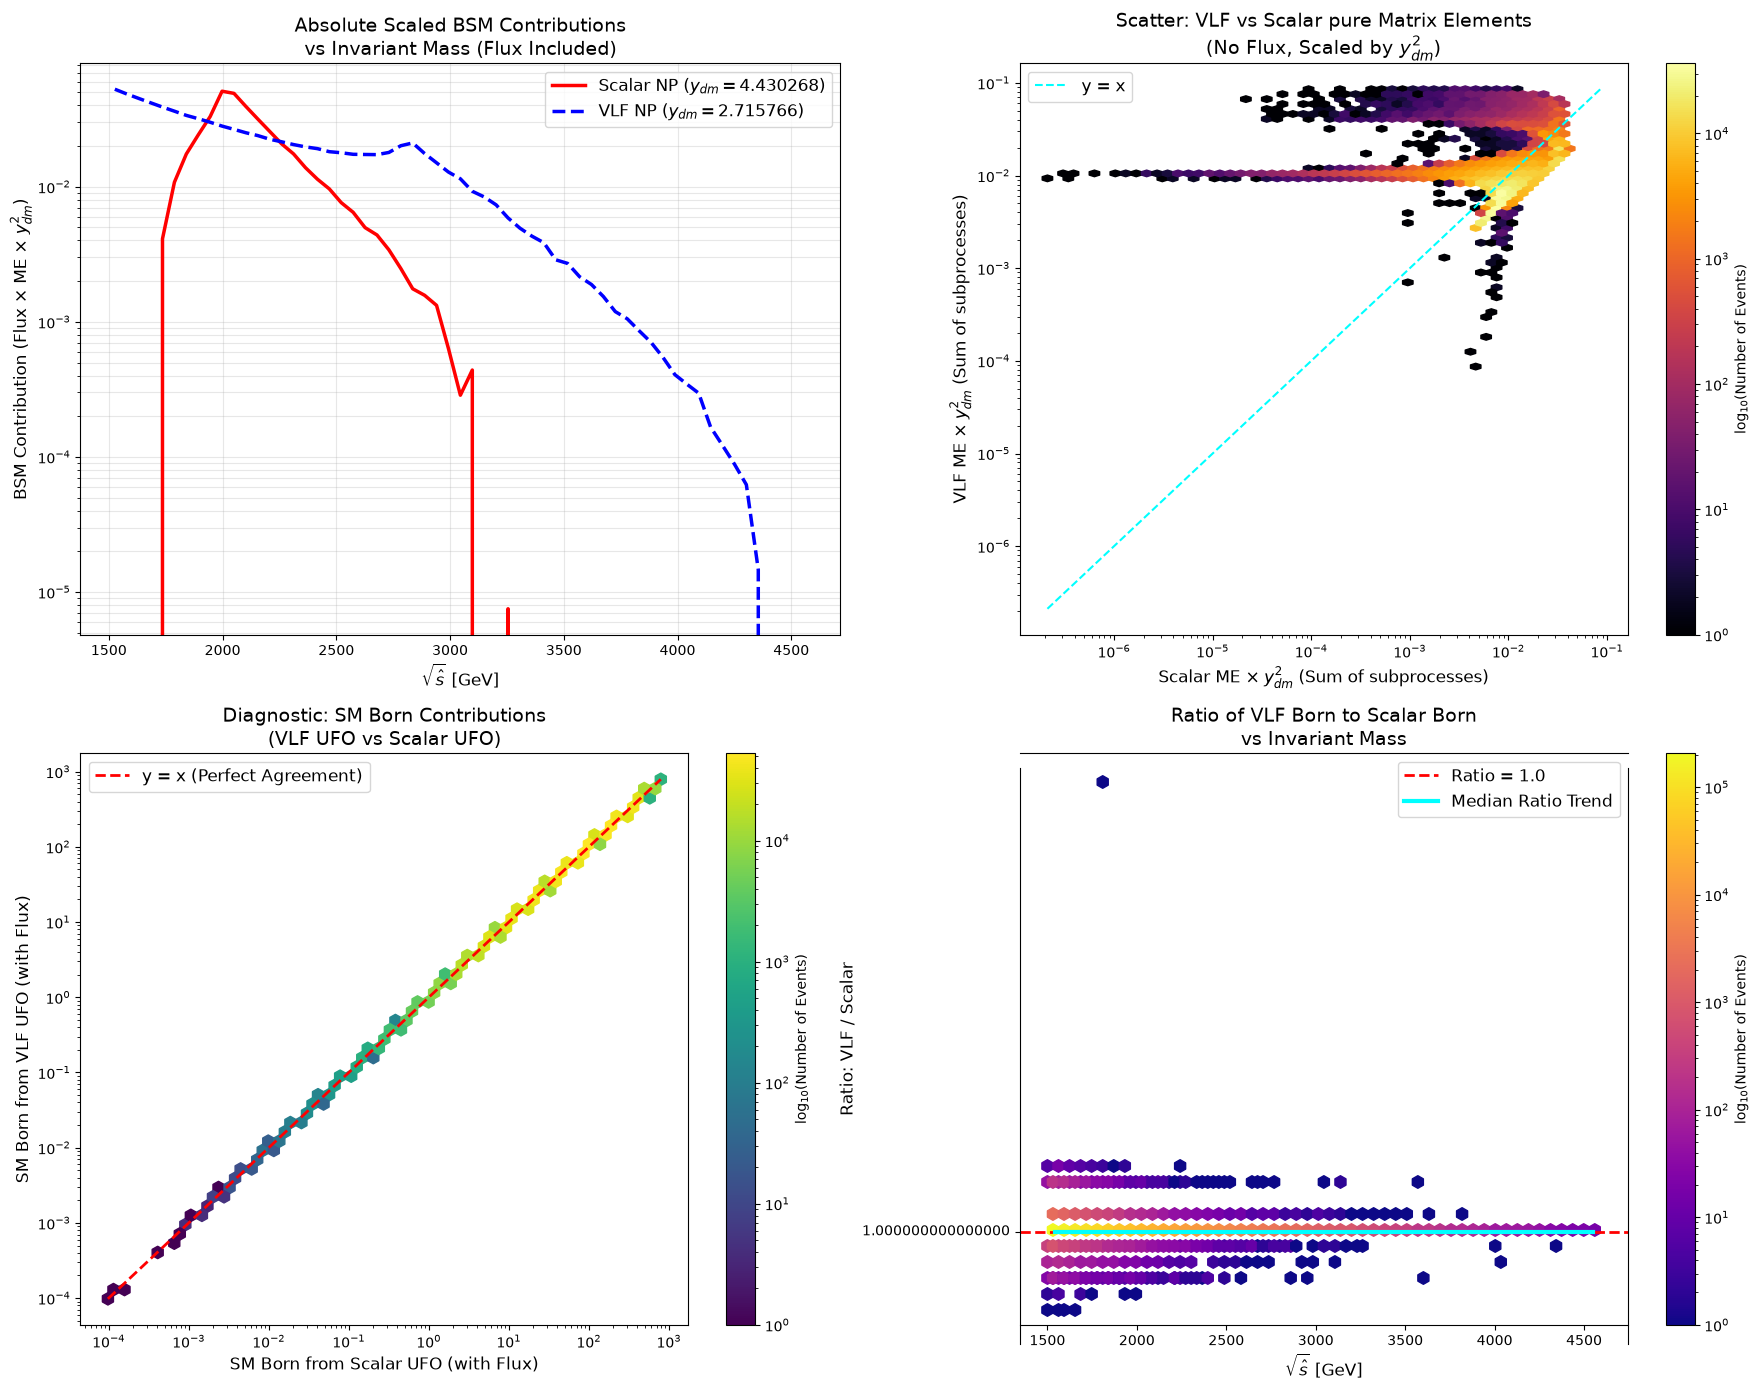

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_swapFix.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing kinematics, fluxes, and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Define Fluxes for Quarks and Gluons
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + df["ME_Finite_VLF_P2_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])
df["SM_Born_VLF_Flux"] = (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + (flux_g * df["ME_Born_VLF_P2_gg_ttx"])

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_VLF_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_VLF_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements (No Flux)
# ---------------------------------------------------------
mask_me = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val2 = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born VLF vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_VLF_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_VLF_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_VLF_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(VLF UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from VLF UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of VLF Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: VLF / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("Checking dataset for swapped matrix elements...")

# Calculate the relative difference assuming they are swapped
# (Scalar P0 vs VLF P2) and (Scalar P2 vs VLF P0)
diff_1 = np.abs(df["ME_Born_Scalar_P0_uux_ttx"] - df["ME_Born_VLF_P2_gg_ttx"]) / df["ME_Born_Scalar_P0_uux_ttx"]
diff_2 = np.abs(df["ME_Born_Scalar_P2_gg_ttx"] - df["ME_Born_VLF_P0_uux_ttx"]) / df["ME_Born_Scalar_P2_gg_ttx"]

# Set a very tight tolerance (e.g., 0.01% difference)
tolerance = 1e-4

# Create a boolean mask for rows where BOTH columns are swapped
mask_swapped = (diff_1 < tolerance) & (diff_2 < tolerance)
total_swapped = mask_swapped.sum()
total_events = len(df)

print(f"Total events in dataset: {total_events}")
print(f"Events where ME is perfectly swapped: {total_swapped}")
print(f"Percentage swapped: {(total_swapped / total_events) * 100:.2f}%")

if total_swapped > 0.99 * total_events:
    print("\nCONCLUSION: The columns are systematically swapped across the entire dataset.")
else:
    print("\nCONCLUSION: The swap is not systematic. Something else is wrong.")

In [26]:
from IPython.display import display

# Calcula a diferença relativa entre as duas colunas
relative_diff = np.abs(df["SM_Born_VLF_Flux"] - df["SM_Born_Scalar_Flux"]) / df["SM_Born_Scalar_Flux"]

# Filtra o DataFrame para pegar apenas os pontos com divergência maior que 1%
df_mismatch = df[relative_diff > 0.01]

# Seleciona as colunas mais importantes para inspecionar o erro
columns_to_show = [
    "sqrt_s_hat", 
    "SM_Born_Scalar_Flux", 
    "SM_Born_VLF_Flux", 
    "ME_Born_Scalar_P0_uux_ttx", 
    "ME_Born_VLF_P0_uux_ttx",
    "ME_Born_Scalar_P2_gg_ttx",
    "ME_Born_VLF_P2_gg_ttx"
]

# Configura o pandas para não truncar as colunas e aumentar a largura da linha
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("==================================================")
print(f"Total de eventos com divergência (glitch): {len(df_mismatch)}")
print("==================================================")
print("Abaixo estão 10 exemplos das linhas com problema:")

# Usa o display para renderizar a tabela completa
display(df_mismatch[columns_to_show].head(10))

# Retorna as configurações do pandas para o padrão (opcional)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

Total de eventos com divergência (glitch): 939305
Abaixo estão 10 exemplos das linhas com problema:


,sqrt_s_hat,SM_Born_Scalar_Flux,SM_Born_VLF_Flux,ME_Born_Scalar_P0_uux_ttx,ME_Born_VLF_P0_uux_ttx,ME_Born_Scalar_P2_gg_ttx,ME_Born_VLF_P2_gg_ttx
50000,1654.684738,7.564065,7.045462,0.403296,0.539115,0.539114,0.403300
50001,1560.865921,13.764273,12.413832,0.404586,0.524127,0.524126,0.404589
50002,1513.147502,252.672691,123.842258,0.750374,11.175278,11.175059,0.750377
50003,1757.915695,233.052026,117.854923,0.778240,19.479744,19.479268,0.778247
50004,2005.127971,2.620248,2.540885,0.370242,0.449175,0.449174,0.370254
50005,1590.822088,113.126160,81.959039,0.753092,12.584111,12.583860,0.753096
50006,1567.870294,220.619742,96.614155,0.717099,8.669405,8.669276,0.717103
50007,1764.185517,133.135069,66.804839,0.714111,10.309272,10.309127,0.714119
50009,1623.684360,34.568291,22.488317,0.540742,1.771372,1.771364,0.540746
50010,1708.877436,144.868800,78.908483,0.732965,11.773772,11.773576,0.732971


In [31]:
import numpy as np

print("Checking dataset for swapped matrix elements...")

# Calculate the relative difference assuming they are swapped
# (Scalar P0 vs VLF P2) and (Scalar P2 vs VLF P0)
diff_1 = np.abs(df["ME_Born_Scalar_P0_uux_ttx"] - df["ME_Born_VLF_P2_gg_ttx"]) / df["ME_Born_Scalar_P0_uux_ttx"]
diff_2 = np.abs(df["ME_Born_Scalar_P2_gg_ttx"] - df["ME_Born_VLF_P0_uux_ttx"]) / df["ME_Born_Scalar_P2_gg_ttx"]

# Set a very tight tolerance (e.g., 0.01% difference)
tolerance = 1e-4

# Create a boolean mask for rows where BOTH columns are swapped
mask_swapped = (diff_1 < tolerance) & (diff_2 < tolerance)
total_swapped = mask_swapped.sum()
total_events = len(df)

print(f"Total events in dataset: {total_events}")
print(f"Events where ME is perfectly swapped: {total_swapped}")
print(f"Percentage swapped: {(total_swapped / total_events) * 100:.2f}%")

if total_swapped > 0.99 * total_events:
    print("\nCONCLUSION: The columns are systematically swapped across the entire dataset.")
else:
    print("\nCONCLUSION: The swap is not systematic. Something else is wrong.")

Checking dataset for swapped matrix elements...
Total events in dataset: 1000000
Events where ME is perfectly swapped: 232820
Percentage swapped: 23.28%

CONCLUSION: The swap is not systematic. Something else is wrong.


In [32]:
# 1. How many are perfectly correct (No Swap, Diff < 0.01)
mask_correct = (relative_diff < 0.01)
total_correct = mask_correct.sum()

# 2. How many are perfectly swapped (from your previous test)
total_swapped = mask_swapped.sum()

# 3. How many are completely corrupted (neither correct nor swapped)
mask_corrupted = ~(mask_correct | mask_swapped)
total_corrupted = mask_corrupted.sum()

print("=== EXTRACTION DAMAGE REPORT ===")
print(f"Total Events:   {len(df)}")
print(f"Perfect Match:  {total_correct} ({(total_correct/len(df))*100:.2f}%)")
print(f"Perfect Swap:   {total_swapped} ({(total_swapped/len(df))*100:.2f}%)")
print(f"Total Garbage:  {total_corrupted} ({(total_corrupted/len(df))*100:.2f}%)")

print("\nSample of the 'Total Garbage' events:")
display(df[mask_corrupted][columns_to_show].head(5))

=== EXTRACTION DAMAGE REPORT ===
Total Events:   1000000
Perfect Match:  60695 (6.07%)
Perfect Swap:   232820 (23.28%)
Total Garbage:  712347 (71.23%)

Sample of the 'Total Garbage' events:


,sqrt_s_hat,SM_Born_Scalar_Flux,SM_Born_VLF_Flux,ME_Born_Scalar_P0_uux_ttx,ME_Born_VLF_P0_uux_ttx,ME_Born_Scalar_P2_gg_ttx,ME_Born_VLF_P2_gg_ttx
50021,2635.994673,54.845448,43.527399,0.783945,45.754711,45.753548,0.785017
50038,2852.942171,1.426928,1.533306,0.522960,2.636592,2.636586,0.533824
50059,2510.045305,2.916929,2.734142,0.518368,2.205951,2.205945,0.518625
50062,2939.030342,1.296971,1.581501,0.552951,3.793779,3.793769,0.554835
50064,2511.650501,37.678289,36.708256,0.776666,38.437210,38.436298,0.776967


# Including Systematics

In [69]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz"
OUTPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_Profiled_Scan.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P2_uux_ttx", "P3_ddx_ttx", "P0_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
SYS_ERRORS = [0.0, 0.02, 0.05, 0.1, 0.3]  # The list of epsilons to scan

# Luminosity Setup
LUMI_FB = 500.0 
LUMI_PB = LUMI_FB * 1000.0
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
df = df[df["mg_weight"] >= 0].reset_index(drop=True)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()
print(f"Kept {len(df)} events with positive weights.")

# ==========================================
# 3. PRECOMPUTE BASE PROBABILITIES (Runs Once)
# ==========================================
print("Precomputing Base Matrix Elements...")
for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        if model == "Zprime":
            sm_col, bsm_col = f"ME_Born_SM_{model}_{ch}", f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col, bsm_col = f"ME_Born_{model}_{ch}", f"ME_Finite_{model}_{ch}"
            
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    df[f"P_SM_Base_{model}"] = p_sm_total
    df[f"P_BSM_Scaled_{model}"] = p_bsm_leading * scale_factor

# ==========================================
# 4. LOOP OVER EPSILONS (Profile & Compute LLR)
# ==========================================
summary_results = []
eps_safeguard = 1e-300

print(f"\nExpected Total Events: {N_events:.1f} (Lumi = {LUMI_FB} fb^-1)")

for eps in SYS_ERRORS:
    print(f"\n>> Processing Epsilon = {eps}")
    
    # Step A: Analytically Profile Theta for each model
    for model in MODELS.keys():
        A = df[f"P_SM_Base_{model}"] * eps
        B = df[f"P_SM_Base_{model}"] + df[f"P_BSM_Scaled_{model}"]
        
        theta_i = np.where(A > 1e-12, (-B + np.sqrt(B**2 + 4 * A**2)) / (2 * A), 0.0)
        p_prof = B + (A * theta_i)
        penalty_i = 0.5 * (theta_i ** 2)
        
        df[f"Theta_{model}_eps{eps}"] = theta_i
        df[f"P_Prof_{model}_eps{eps}"] = p_prof
        df[f"Penalty_{model}_eps{eps}"] = penalty_i

    # Step B: Compute Log-Likelihood Ratios
    p_base_safe = np.clip(df[f"P_Prof_{BASELINE_MODEL}_eps{eps}"], a_min=eps_safeguard, a_max=None)
    log_p_base = np.log(p_base_safe / sigma_baseline) - df[f"Penalty_{BASELINE_MODEL}_eps{eps}"]
    
    for model in MODELS.keys():
        p_targ_safe = np.clip(df[f"P_Prof_{model}_eps{eps}"], a_min=eps_safeguard, a_max=None)
        log_p_targ = np.log(p_targ_safe / CROSS_SECTIONS[model]) - df[f"Penalty_{model}_eps{eps}"]
        
        llr_norm = log_p_targ - log_p_base
        weighted_llr = df["w_i"] * llr_norm
        
        df[f"Weighted_LLR_{model}_eps{eps}"] = weighted_llr
        
        # Step C: Extract Significance
        llr_1event = weighted_llr.sum()
        total_llr = llr_1event * N_events
        sig = np.sqrt(-2 * total_llr) if total_llr < 0 else 0.0
        
        mean_theta = df[f"Theta_{model}_eps{eps}"].mean()
        
        summary_results.append({
            "Model": model,
            "Epsilon": eps,
            "Mean_Theta": mean_theta,
            "Significance": sig
        })

# ==========================================
# 5. PRINT SUMMARY & SAVE
# ==========================================
df_summary = pd.DataFrame(summary_results)

print("\n" + "="*50)
print("ASIMOV SIGNIFICANCE (Z-SCORE) VS. SYSTEMATIC ERROR")
print("="*50)
# Create a beautiful pivot table showing Models as rows and Epsilons as columns
pivot_sig = df_summary.pivot(index="Model", columns="Epsilon", values="Significance")
print(pivot_sig.to_string(float_format="%.2f"))

print("\n" + "="*50)
print("MEAN THETA VS. SYSTEMATIC ERROR (BIAS CHECK)")
print("="*50)
pivot_theta = df_summary.pivot(index="Model", columns="Epsilon", values="Mean_Theta")
print(pivot_theta.to_string(float_format="%+.4f"))
print("="*50)

# Clean up memory by dropping base columns if desired, but we'll save it all
df.to_csv(OUTPUT_CSV, index=False, compression='infer')
print(f"\nSaved massive profiled dataset to: {OUTPUT_CSV}")

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz...
Kept 3155491 events with positive weights.
Precomputing Base Matrix Elements...

Expected Total Events: 630629.5 (Lumi = 500.0 fb^-1)

>> Processing Epsilon = 0.0

>> Processing Epsilon = 0.02

>> Processing Epsilon = 0.05

>> Processing Epsilon = 0.1

>> Processing Epsilon = 0.3

ASIMOV SIGNIFICANCE (Z-SCORE) VS. SYSTEMATIC ERROR
Epsilon   0.00   0.02   0.05   0.10   0.30
Model                                     
Scalar    0.00   0.00   0.00   0.00   0.00
VLF      88.01  88.01  87.97  87.86  86.85
Zprime  105.97 105.96 105.91 105.74 104.18

MEAN THETA VS. SYSTEMATIC ERROR (BIAS CHECK)
Epsilon    0.00    0.02    0.05    0.10    0.30
Model                                          
Scalar  +0.0000 +0.0197 +0.0492 +0.0976 +0.2733
VLF     +0.0000 +0.0198 +0.0494 +0.0980 +0.2744
Zprime  +0.0000 +0.0199 +0.0496 +0.0984 +0.2752

Saved massive profiled dataset to: /home/vinicius/UnfoldingBSMttbar/Likeliho

In [35]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------


KeyError: 'Weighted_LLR_VLF'

In [10]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
LUMI_FB = 500.0 
LUMI_PB = LUMI_FB * 1000.0 
EPSILON = 1e-300

print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
df = df[df["mg_weight"] >= 0].reset_index(drop=True)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

if "sqrt_s_hat" not in df.columns:
    df["sqrt_s_hat"] = np.sqrt(df["s_hat"])


# ==========================================
# 2. RAW PROBABILITIES & SYSTEMATICS
# ==========================================

# -- Option 1: Scale-dependent shape error (from invariant mass) --
x_val = np.minimum(df["sqrt_s_hat"].values, 2750.0)
df["sys_shape"] = ((1.43e-06 * (x_val**2)) + (6.18e-03 * x_val) + 4.81) / 100.0

# -- Option 2: Flat systematic error (e.g., 10%) --
df["sys_flat"] = 0.1 

# --- SWITCH SYSTEMATIC ERROR HERE ---
ACTIVE_SYS = "sys_shape"  # Change to "sys_flat" to use the constant 10% error
deltas = df[ACTIVE_SYS].values

print(f"Applying systematic error: {ACTIVE_SYS}")

for model, channels in MODELS.items():
    scale_factor = Y_DM_CONFIG[model]["y_dm"] ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        if model == "Zprime":
            p_sm_total += flux * df[f"ME_Born_SM_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Born_NP_{model}_{ch}"]
        else:
            p_sm_total += flux * df[f"ME_Born_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Finite_{model}_{ch}"]
            
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_{model}"] = p_bsm_leading * scale_factor

# ==========================================
# 3. EXACT EVENT-BY-EVENT PROFILING
# ==========================================
def profile_events_analytically(p_sm, p_bsm, sys_array):
    """
    Computes the exact event-by-event optimal nuisance parameters (theta_i) 
    using the analytical quadratic solution.
    """
    A = p_sm * sys_array
    B = p_sm + p_bsm
    
    # Safe division mapping to avoid divide-by-zero where A is 0
    theta_i = np.where(
        A > 1e-12, 
        (-B + np.sqrt(B**2 + 4 * A**2)) / (2 * A), 
        0.0
    )
    
    p_prof = B + (A * theta_i)
    
    # The penalty is strictly the squared shift (we apply the weights in Step 4)
    raw_penalty = 0.5 * (theta_i**2)
    
    return np.clip(p_prof, EPSILON, None), raw_penalty, theta_i

# ==========================================
# 4. COMPUTE JOINT LLR
# ==========================================
print("\n" + "="*60)
print("COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR")
print("="*60)

sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_EVENTS_BASE = sigma_baseline * LUMI_PB
w_i = df["w_i"].values

# FIXED: Correctly assign the full BSM component to the Baseline Model
p_sm_base = df[f"P_SM_{BASELINE_MODEL}"].values
p_bsm_base = df[f"P_BSM_{BASELINE_MODEL}"].values  

p_prof_base, raw_penalty_base, thetas_base = profile_events_analytically(p_sm_base, p_bsm_base, deltas)

# Normalize baseline cross-section dynamically based on the shifted weights
sigma_prof_base = sigma_baseline * np.sum(w_i * (p_prof_base / np.clip(p_sm_base + p_bsm_base, EPSILON, None)))
log_p_base = np.log(p_prof_base / sigma_prof_base)

# FIXED: Multiply the raw penalty by the expected physical event yield (N * w_i)
weighted_penalty_base = N_EVENTS_BASE * w_i * raw_penalty_base
nll_base_total = -np.sum(N_EVENTS_BASE * w_i * log_p_base) + np.sum(weighted_penalty_base)

for model in MODELS.keys():
    if model == BASELINE_MODEL:
        # We can still print the baseline vs baseline validation check
        print(f"Model: {model} [BASELINE]")
        print(f"  -> Profiled Joint LLR       : 0.00")
        print(f"  -> Avg Baseline Nuisance    : {np.mean(thetas_base):+.5f} sigma")
        print("-" * 60)
        continue
        
    p_sm_target = df[f"P_SM_{model}"].values
    p_bsm_target = df[f"P_BSM_{model}"].values
    sigma_target = CROSS_SECTIONS[model]
    
    # Profile the Target Model
    p_prof_target, raw_penalty_target, thetas_target = profile_events_analytically(p_sm_target, p_bsm_target, deltas)
    
    # Normalize target cross-section dynamically
    sigma_prof_target = sigma_target * np.sum(w_i * (p_prof_target / np.clip(p_sm_target + p_bsm_target, EPSILON, None)))
    log_p_target = np.log(p_prof_target / sigma_prof_target)
    
    # FIXED: Multiply the raw penalty by the expected physical event yield
    weighted_penalty_target = N_EVENTS_BASE * w_i * raw_penalty_target
    nll_target_total = -np.sum(N_EVENTS_BASE * w_i * log_p_target) + np.sum(weighted_penalty_target)
    
    # Profiled LLR
    joint_llr = -(nll_target_total - nll_base_total)
    significance = np.sqrt(-2 * joint_llr) if joint_llr < 0 else 0.0
    
    print(f"Model: {model}")
    print(f"  -> Profiled Joint LLR       : {joint_llr:.2f}")
    print(f"  -> Avg Target Nuisance      : {np.mean(thetas_target):+.5f} sigma")
    print(f"  -> Profiled Significance    : {significance:.2f} sigma")
    print("-" * 60)

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Applying systematic error: sys_shape

COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR
Model: VLF
  -> Profiled Joint LLR       : -995.23
  -> Avg Target Nuisance      : +0.19807 sigma
  -> Profiled Significance    : 44.61 sigma
------------------------------------------------------------
Model: Scalar [BASELINE]
  -> Profiled Joint LLR       : 0.00
  -> Avg Baseline Nuisance    : +0.19733 sigma
------------------------------------------------------------
Model: Zprime
  -> Profiled Joint LLR       : -1864.18
  -> Avg Target Nuisance      : +0.19880 sigma
  -> Profiled Significance    : 61.06 sigma
------------------------------------------------------------


In [36]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.496146e-03
  -> Total Log-Likelihood    : -943.51
  -> Asimov Significance     : 43.44 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.786289e-03
  -> Total Log-Likelihood    : -1757.12
  -> Asimov Significance     : 59.28 sigma
------------------------------------------------------------


Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_1.csv.gz...
Loaded 1000000 events.
Computing and plotting...


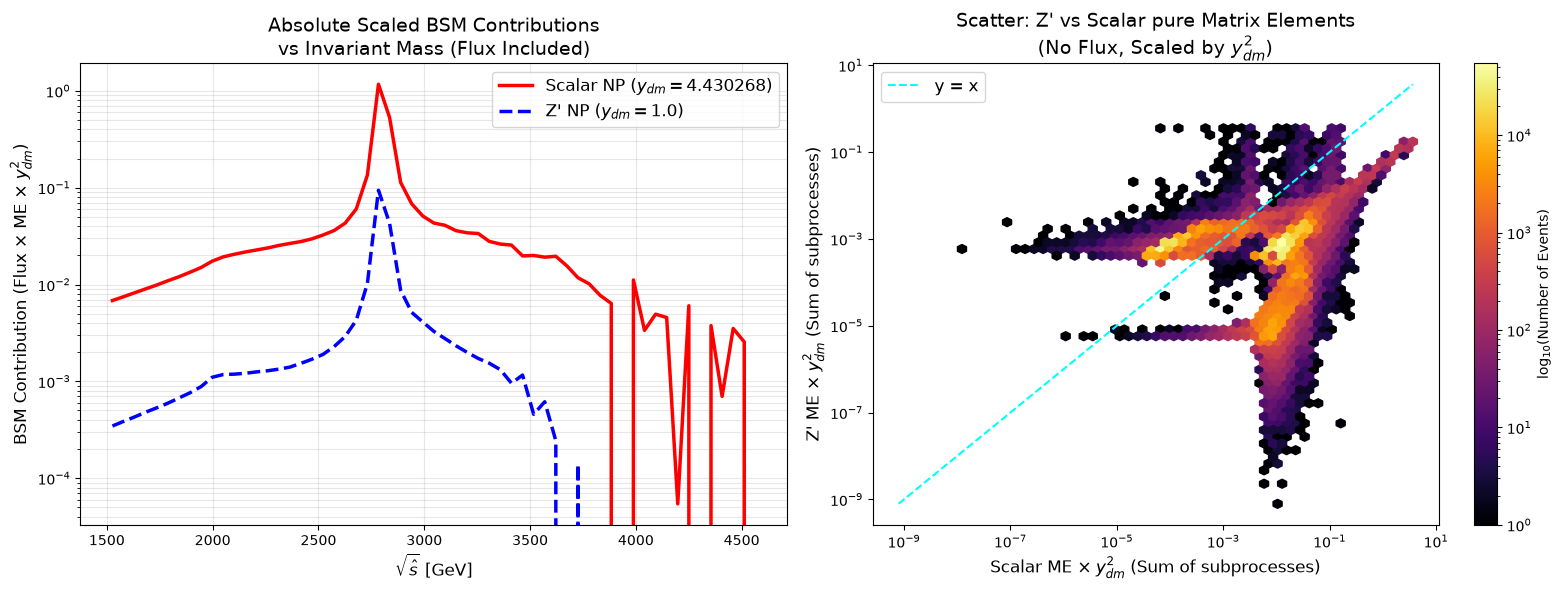

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_1.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    ( df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    ( df["ME_Born_NP_Zprime_P3_ddx_ttx"]) +
    (df["ME_Born_NP_Zprime_P0_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Z' NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_Zprime_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_Zprime_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_Zprime_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_Zprime_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Z' vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("Z' ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155477 events.
Computing and plotting...


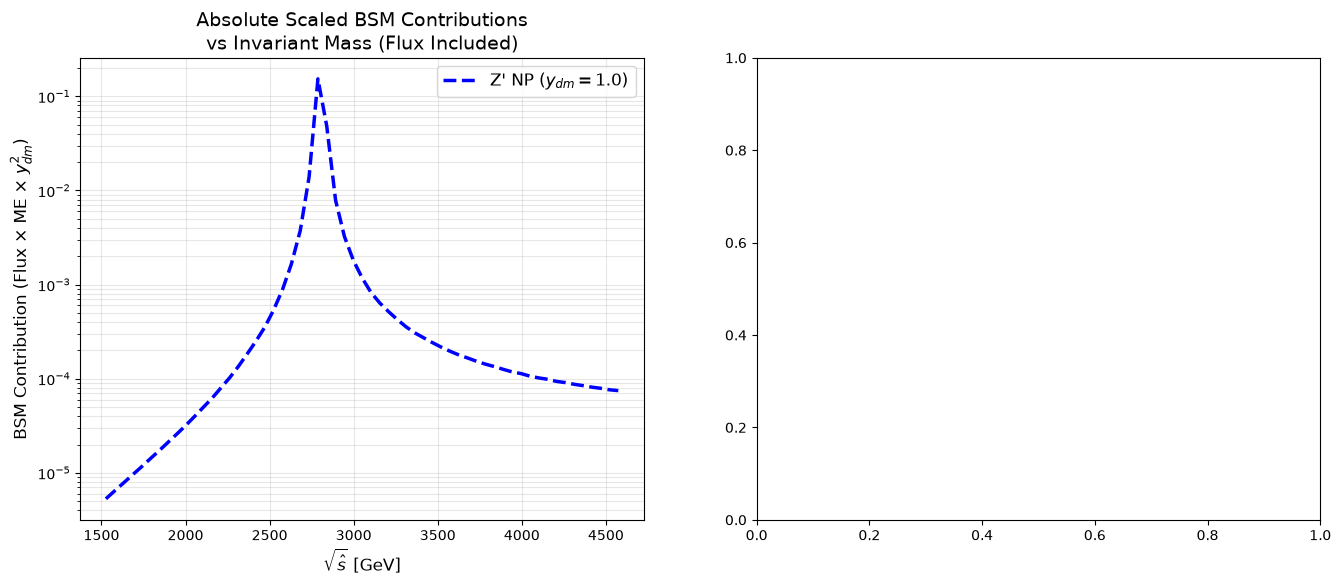

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    ( df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    ( df["ME_Born_NP_Zprime_P3_ddx_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

#profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

#ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Z' NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')


plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_1.csv.gz...
Loaded 1000000 events.
Computing and plotting...


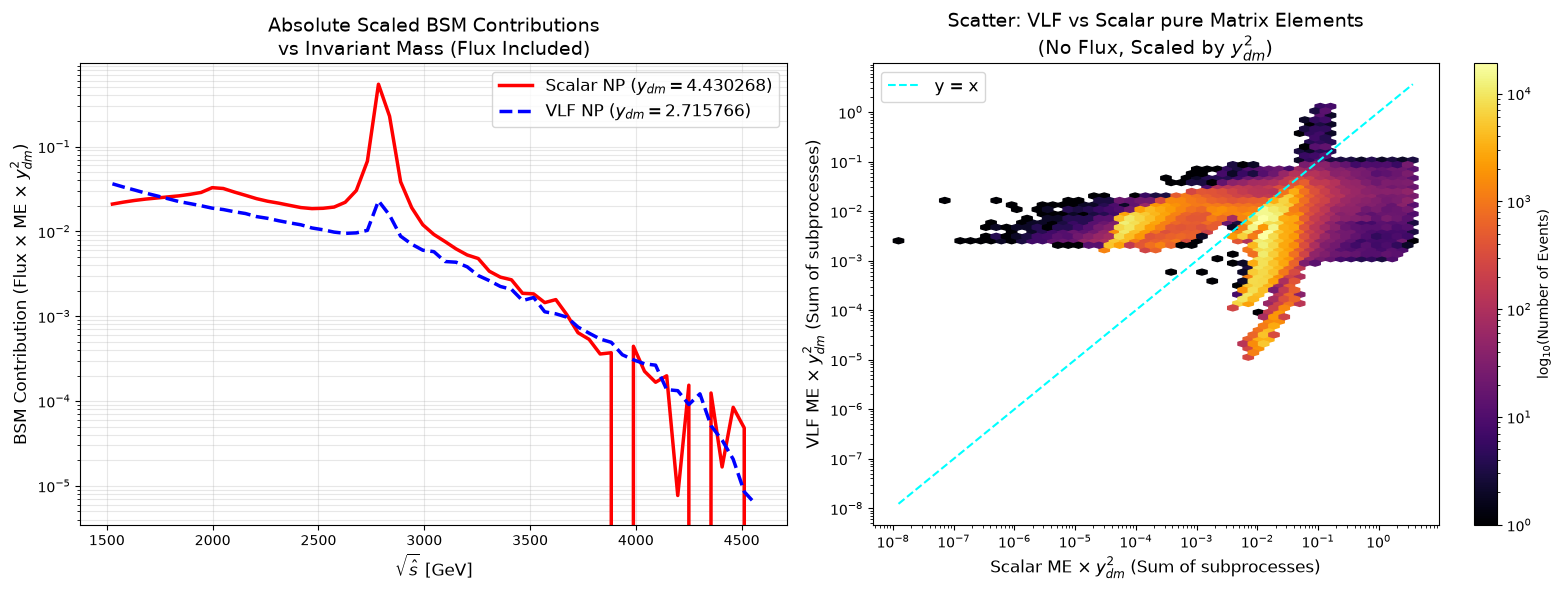

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Unweighted/Matrix_AllModels_FF_1.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + 
    df["ME_Finite_VLF_P2_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz...
Loaded 3155536 events.
Computing and plotting...


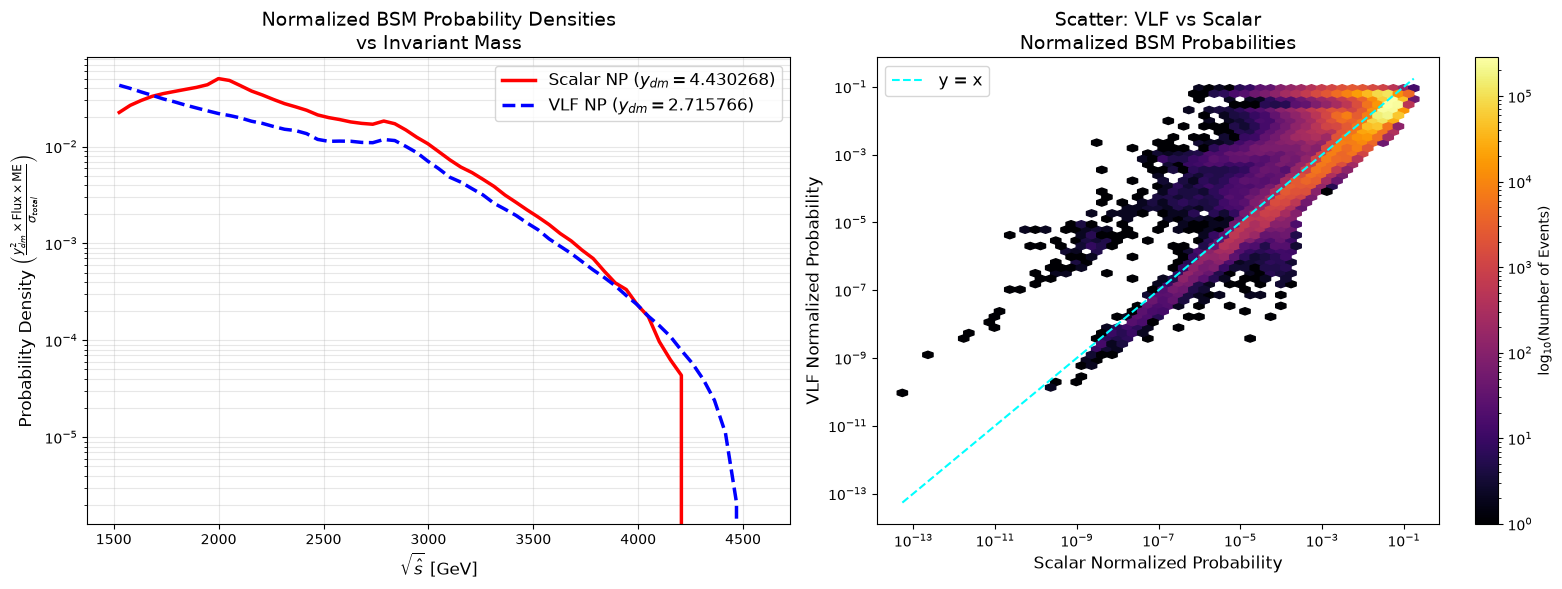

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE NORMALIZED CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Apply the flavor symmetry sum for the quark initial states
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# Compute fully normalized BSM probabilities: (Scale * Flux * ME) / Sigma_Total
df["Norm_Prob_Scalar"] = (scale_scalar / CROSS_SECTIONS["Scalar"]) * (
    (flux_q * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (flux_g * df["ME_Finite_Scalar_P2_gg_ttx"])
)

df["Norm_Prob_VLF"] = (scale_vlf / CROSS_SECTIONS["VLF"]) * (
    (flux_q * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (flux_g * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

# Group by the bins to get the mean profile
profile_scalar = df.groupby('s_hat_bin', observed=False)['Norm_Prob_Scalar'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['Norm_Prob_VLF'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Normalized BSM Probability Densities\nvs Invariant Mass", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("Probability Density $\\left(\\frac{y_{dm}^2 \\times \\text{Flux} \\times \\text{ME}}{\\sigma_{total}}\\right)$", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Normalized Probabilities
# ---------------------------------------------------------
# Filter out exact zeros or negatives to safely use a log-log scale
mask = (df["Norm_Prob_Scalar"] > 0) & (df["Norm_Prob_VLF"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["Norm_Prob_Scalar"], df_scatter["Norm_Prob_VLF"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line to see which model dominates
min_val = min(df_scatter["Norm_Prob_Scalar"].min(), df_scatter["Norm_Prob_VLF"].min())
max_val = max(df_scatter["Norm_Prob_Scalar"].max(), df_scatter["Norm_Prob_VLF"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar\nNormalized BSM Probabilities", fontsize=14)
ax2.set_xlabel("Scalar Normalized Probability", fontsize=12)
ax2.set_ylabel("VLF Normalized Probability", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

In [27]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
from tqdm import tqdm

# --- LHAPDF Path Setup ---
# Replace with your actual LHAPDF installation path if different
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & MODEL REGISTRY SETUP
# ==========================================
E_BEAM = 6500.0    # Beam energy in GeV (e.g., 6500 for 13 TeV LHC)
PDF_NAME = 244600  # Must match the PDF set used in your MG5 event generation

# Fixed Renormalization & Factorization Scale 
MU_F  = 91.188     # Factorization scale in GeV (used ONLY for LHAPDF parton densities)
MU_R  = 91.188    # Renormalization scale in GeV (used for LHAPDF alpha_s)
MU_R2 = MU_R**2    # Renormalization scale squared in GeV^2 (used for MadLoop virtuals)   # Scale squared in GeV^2 (used for MadLoop virtuals)

# Define absolute root paths for all 3 model hypotheses
MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/test_nlo_MatrixElements/SubProcesses")
}

# Define production channels (using P1_ indexing for Zprime as confirmed earlier)
MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": [
        "P2_uux_ttx", 
        "P3_ddx_ttx", 
        "P0_gg_ttx"
    ]
}

# Map MadGraph directory prefixes to their corresponding PDG quark IDs for PDF lookup
PDG_MAP = {
    "uux": 2,  # Up
    "ddx": 1,  # Down
    "ssx": 3,  # Strange
    "ccx": 4,  # Charm
    "bbx": 5   # Bottom
}

# ==========================================
# 2. UNIVERSAL LIBRARY LOADER & INITIALIZER
# ==========================================

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p
def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def load_all_models(roots_dict, channels_dict):
    """Loads and compiles all matrix_*.so libraries into a unified dictionary registry."""
    registry = {}
    print("Loading Matrix Element Libraries...\n" + "="*50)
    for model_name, root_dir in roots_dict.items():
        print(f" -> Loading Model: [{model_name}]")
        registry[model_name] = {}
        for channel in channels_dict[model_name]:
            subproc_path = os.path.join(root_dir, channel)
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
            
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files:
                raise FileNotFoundError(f"No compiled .so library found in {subproc_path}")
            
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]  # Strip architecture tags
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {channel}")
            registry[model_name][channel] = {
                "module": mod,
                "path": subproc_path
            }
            print(f"    [✓] {channel}")
    print("="*50 + "\n")
    return registry

# Initialize global model registry
models = load_all_models(MODEL_ROOTS, MODEL_CHANNELS)

Loading Matrix Element Libraries...
 -> Loading Model: [VLF]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Scalar]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Zprime]
    [✓] P2_uux_ttx
    [✓] P3_ddx_ttx
    [✓] P0_gg_ttx



In [29]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03,  0.1041545E+03,  0.4176826E+03, -0.1873741E+03],
    [0.5000000E+03, -0.1041545E+03, -0.4176826E+03,  0.1873741E+03]
]

#p_user_lab = [
 #   [0.5000000E+03,  0.0000000E+00,   0.0000000E+00,  0.5000000E+03],
  #  [0.5000000E+03,  0.0000000E+00,   0.0000000E+00, -0.5000000E+03],
   # [0.5000000E+03, -0.1773983e-306, -0.1736952E+03, -0.4361720E+03],
   # [0.5000000E+03,  0.1773983e-306,  0.1736952E+03,  0.4361720E+03]
#]
p_user_lab = [
    [1.1531302741E+02,  0.0000000000E+00,  0.0000000000E+00,  1.1531302741E+02],  # ubar (initial)
    [5.1757384408E+03,  0.0000000000E+00,  0.0000000000E+00, -5.1757384408E+03],  # u    (initial)
    [5.0065023091E+02, -3.2209408283E+02, -1.8605514968E+02, -2.8758570338E+02],  # t    (final)
    [4.7904012373E+03,  3.2209408283E+02,  1.8605514968E+02, -4.7728397100E+03]   # tbar (final)
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, model_name, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (StandAlone get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_flat = np.ravel(res)
            
            print(f"Debug Raw Array ({model_name} / {os.path.basename(subproc_path)}): {res_flat.tolist()}")
            
            # ---------------------------------------------------------
            # BRANCH 1: Z-PRIME MODEL SPECIFIC LOGIC
            # ---------------------------------------------------------
            if "z_prime" in model_name.lower() or "zprime" in model_name.lower():
                
                # Z-prime CASE A: 2-element array (gg subprocess)
                if res_flat.size == 2:
                    born_val   = float(res_flat[0]) # Total / SM Born
                    finite_val = 0 # Z' contribution
                    pole1_val  = 0.0
                    pole2_val  = 0.0
                    m_type     = "Z' NLO (gg, 2-comp)"

                # Z-prime CASE B: 4-element array (uux / ddx subprocesses)
                # Layout: [Total, Pure Z', Interference, Pure SM]
                elif res_flat.size == 4:
                    born_val   = float(res_flat[3]) # Pure SM Born
                    finite_val = float(res_flat[1]) # Pure Z'
                    pole1_val  = float(res_flat[2]) # Interference stored in Single Pole column
                    pole2_val  = 0.0
                    m_type     = "Z' NLO (qqbar, 4-comp)"

                else:
                    born_val   = float(res_flat[0]) if len(res_flat) > 0 else 0.0
                    finite_val = float(res_flat[1]) if len(res_flat) > 1 else 0.0
                    pole1_val  = 0.0
                    pole2_val  = 0.0
                    m_type     = f"Z' NLO ({res_flat.size}-comp)"

            # ---------------------------------------------------------
            # BRANCH 2: SCALAR, VLF, AND STANDARD MADLOOP MODELS
            # ---------------------------------------------------------
            else:
                # Standard MadLoop Layout: [Born, Finite, Pole1, Pole2]
                born_val   = float(res_flat[0]) if len(res_flat) > 0 else 0.0
                finite_val = float(res_flat[1]) if len(res_flat) > 1 else 0.0
                pole1_val  = float(res_flat[2]) if len(res_flat) > 2 else 0.0
                pole2_val  = float(res_flat[3]) if len(res_flat) > 3 else 0.0
                m_type     = "NLO (MadLoop)"
            
            return {
                "Type": m_type,
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": res_flat.tolist()
            }
            
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            # We now pass model_name into the unpacker so it knows which array format to expect
            comps = eval_full_me_components(mod_dict, model_name, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.4e}",
            "BSM Born / Finite": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.7, -3.22e+02, -186.1, -287.6] GeV

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
Debug Raw Array (VLF / P0_uux_ttx): [0.863998855926552, 0.0010332013447346667, 9.348232064986127e-17, 0.0]
Debug Raw Array (VLF / P2_gg_ttx): [3.9469981837839048, 0.00010484394335145165, -3.0401583630893745e-15, 0.0]
Debug Raw Array (Scalar / P0_uux_ttx): [0.863998855926552, 0.0006631586633893028, 1.6460598316491036e-16, 0.0]
Debug Raw Array (Scalar / P2_gg_ttx): [3.9469981837839048, -7.683922312382474e-05, 2.507056897353015e-15, 0.0]
Debug Raw Array (Zprime / P2_uux_ttx): [0.8844505937500851, 0.020451737823533066, -3.0961124747126855e-17, 0.863998855926552]
Debug Raw Array (Zprime / P3_ddx_ttx): [0.88445

In [14]:
import numpy as np
import pandas as pd
import time
import os
import glob
import h5py
from scipy.optimize import minimize

class ProfileLikelihoodFitter:
    def __init__(self, h5_filepath, mass_hypothesis, L_int, test_model='Scalar', true_model='Scalar', true_mass="1000", mu_true=(4.430268)**2):
        self.L_int = L_int
        self.mass = str(mass_hypothesis)     
        self.true_mass = str(true_mass)      
        self.test_model = test_model
        self.true_model = true_model
        self.mu_true = mu_true
        
        # Maps the channel folder names to the flux array index in PDF/Nominal
        self.ch_map = {
            "Scalar": {"P0_uux_ttx": 1, "P2_gg_ttx": 0},
            "VLF": {"P0_uux_ttx": 1, "P2_gg_ttx": 0},
            "Zprime": {"P2_uux_ttx": 1, "P3_ddx_ttx": 2, "P0_gg_ttx": 0}
        }
        
        self._load_and_precompute(h5_filepath)

    def _get_safe_event_count(self, f):
        """Scans the HDF5 file to find the minimum array length, salvaging partially-appended files."""
        lengths = [
            len(f['Events/Kinematics']),
            len(f['PDF/Nominal']),
            len(f['PDF/Replicas_Ratio']),
            len(f['Scale/Flux_Ratio'])
        ]
        
        # Check lengths for both the test mass and the true mass to ensure complete safety
        for model, check_mass in [(self.test_model, self.mass), (self.true_model, self.true_mass), ('Scalar', self.true_mass)]:
            for ch in self.ch_map[model].keys():
                base_path = f"MatrixElements/{model}/{ch}"
                if f"{base_path}/M{check_mass}_BSM" in f:
                    lengths.append(len(f[f"{base_path}/M{check_mass}_BSM"]))
                if f"{base_path}/SM_7scales" in f:
                    lengths.append(len(f[f"{base_path}/SM_7scales"]))
                    
        return min(lengths)

    def _extract_model_observables(self, f, model_name, target_mass, N_events, chunk_size=50000, compute_pdf_vars=False):
        """Processes observables in chunks to minimize RAM usage."""
        sm_nom = np.zeros(N_events)
        bsm_nom = np.zeros(N_events)
        sm_scale = np.zeros((N_events, 7))
        
        var_sm = np.zeros(N_events) if compute_pdf_vars else None
        var_bsm = np.zeros(N_events) if compute_pdf_vars else None
        cov_sm_bsm = np.zeros(N_events) if compute_pdf_vars else None
        
        for start in range(0, N_events, chunk_size):
            end = min(start + chunk_size, N_events)
            
            flux_nom_chunk = f['PDF/Nominal'][start:end]
            scale_ratios_chunk = f['Scale/Flux_Ratio'][start:end]
            
            if compute_pdf_vars:
                pdf_ratios_chunk = f['PDF/Replicas_Ratio'][start:end]
                sm_pdf_chunk = np.zeros((end - start, 100))
                bsm_pdf_chunk = np.zeros((end - start, 100))
            
            for ch, f_idx in self.ch_map[model_name].items():
                base_path = f"MatrixElements/{model_name}/{ch}"
                
                # --- Zprime SM Component Redirection ---
                if model_name == "Zprime":
                    if ch in ["P2_uux_ttx", "P3_ddx_ttx"]:
                        sm_path = f"MatrixElements/Scalar/P0_uux_ttx/SM_7scales"
                    else: # P0_gg_ttx
                        sm_path = f"MatrixElements/Scalar/P2_gg_ttx/SM_7scales"
                else:
                    sm_path = f"{base_path}/SM_7scales"

                me_bsm = np.nan_to_num(f[f"{base_path}/M{target_mass}_BSM"][start:end], nan=0.0)
                me_sm_7 = np.nan_to_num(f[sm_path][start:end], nan=0.0)
                me_sm_nom = me_sm_7[:, 3] 
                
                # --- Flavor Symmetry Summation & Component-wise Clipping ---
                if model_name in ["VLF", "Scalar"] and "uux" in ch:
                    flavor_indices = [1, 2, 3, 4, 5] 
                else:
                    flavor_indices = [f_idx]

                flux_nom_safe = np.zeros(end - start)
                for idx in flavor_indices:
                    flux_nom_safe += np.maximum(0.0, flux_nom_chunk[:, idx])
                
                # 1. Nominal Cross Sections
                sm_nom[start:end] += flux_nom_safe * me_sm_nom
                bsm_nom[start:end] += flux_nom_safe * me_bsm
                
                # 2. Scale Variations
                for s_idx in range(7):
                    flux_scale = np.zeros(end - start)
                    for idx in flavor_indices:
                        flux_scale += np.maximum(0.0, flux_nom_chunk[:, idx] * scale_ratios_chunk[:, idx, s_idx])
                    sm_scale[start:end, s_idx] += flux_scale * me_sm_7[:, s_idx]
                    
                # 3. PDF Replicas
                if compute_pdf_vars:
                    flux_pdf = np.zeros((end - start, 100))
                    for idx in flavor_indices:
                        flux_pdf += np.maximum(0.0, flux_nom_chunk[:, idx, np.newaxis] * pdf_ratios_chunk[:, idx, :])
                    
                    sm_pdf_chunk += flux_pdf * me_sm_nom[:, np.newaxis]
                    bsm_pdf_chunk += flux_pdf * me_bsm[:, np.newaxis]
                    
            if compute_pdf_vars:
                var_sm[start:end] = np.var(sm_pdf_chunk, axis=1, ddof=1)
                var_bsm[start:end] = np.var(bsm_pdf_chunk, axis=1, ddof=1)
                
                mean_sm = np.mean(sm_pdf_chunk, axis=1, keepdims=True)
                mean_bsm = np.mean(bsm_pdf_chunk, axis=1, keepdims=True)
                cov_sm_bsm[start:end] = np.sum((sm_pdf_chunk - mean_sm) * (bsm_pdf_chunk - mean_bsm), axis=1) / 99.0
                
        return sm_nom, bsm_nom, sm_scale, var_sm, var_bsm, cov_sm_bsm

    def _load_and_precompute(self, h5_filepath):
        with h5py.File(h5_filepath, 'r') as f:
            N_events = self._get_safe_event_count(f)
            self.N_MC = N_events
            self.lhe_weights = f['Events/Kinematics'][:N_events, 4] 
            
            # 1. GENERATOR: Scalar at the TRUE_MASS (1000)
            sm_nom_gen, bsm_nom_gen, _, _, _, _ = self._extract_model_observables(
                f, 'Scalar', self.true_mass, N_events, compute_pdf_vars=False)
            self.dsigma_gen = sm_nom_gen + self.mu_true * bsm_nom_gen
            
            # 2. TEST HYPOTHESIS: test_model sweeping across TEST MASS
            self.dsigma_sm_nom, self.dsigma_bsm_nom, sm_scale, self.var_sm, self.var_bsm, self.cov_sm_bsm = \
                self._extract_model_observables(f, self.test_model, self.mass, N_events, compute_pdf_vars=True)
            
            # 3. TRUE UNIVERSE: true_model locked at TRUE_MASS
            sm_nom_true, bsm_nom_true, _, _, _, _ = self._extract_model_observables(
                f, self.true_model, self.true_mass, N_events, compute_pdf_vars=False)
            dsigma_true = sm_nom_true + self.mu_true * bsm_nom_true
            
        # Ensure the generator density never drops below a safe threshold due to destructive interference
        self.safe_dsigma_gen = np.maximum(self.dsigma_gen, 1e-8)
        self.asimov_weights = self.lhe_weights * (dsigma_true / self.safe_dsigma_gen)
            
        max_scale = np.max(sm_scale, axis=1)
        min_scale = np.min(sm_scale, axis=1)
        
        safe_sm_nom = np.where(self.dsigma_sm_nom > 0, self.dsigma_sm_nom, 1e-10)
        
        raw_delta_plus = (max_scale - self.dsigma_sm_nom) / safe_sm_nom
        raw_delta_minus = (self.dsigma_sm_nom - min_scale) / safe_sm_nom
        
        self.delta_scale_plus = np.clip(raw_delta_plus, 0.0, 10.0) 
        self.delta_scale_minus = np.clip(raw_delta_minus, 0.0, 0.99)

    def morphing_factor(self, theta, delta_plus, delta_minus):
        if theta > 1.0: return np.exp(theta * np.log(1.0 + delta_plus))
        elif theta < -1.0: return np.exp(-theta * np.log(1.0 - delta_minus))
        else: return 1.0 + 0.5 * (delta_plus - delta_minus) * theta + 0.5 * (delta_plus + delta_minus) * theta**2

    def calculate_dsigma_dphi(self, mu, theta_scale, theta_pdf):
        # --- FIX 2: Strict Positivity for Yields and Extrapolations ---
        R_scale = self.morphing_factor(theta_scale, self.delta_scale_plus, self.delta_scale_minus)
        R_scale = np.maximum(R_scale, 1e-6) # Never let systematic variations flip yield to negative
        
        sm_morphed = self.dsigma_sm_nom * R_scale
        
        dsigma_nom_mu = self.dsigma_sm_nom + mu * self.dsigma_bsm_nom
        safe_nom_mu = np.where(dsigma_nom_mu > 0, dsigma_nom_mu, 1e-10)
        
        variance = np.maximum(0.0, self.var_sm + (mu**2)*self.var_bsm + 2.0*mu*self.cov_sm_bsm)
        delta_pdf_abs = np.sqrt(variance)
        
        delta_pdf_rel = np.clip(delta_pdf_abs / safe_nom_mu, 0.0, 0.99)
        
        R_pdf = self.morphing_factor(theta_pdf, delta_pdf_rel, delta_pdf_rel)
        R_pdf = np.maximum(R_pdf, 1e-6) # Strict Positivity
        
        final_dsigma = (sm_morphed + mu * self.dsigma_bsm_nom) * R_pdf
        return np.maximum(final_dsigma, 1e-15) # Cap the absolute floor at > 0 to save log(0)

    def negative_log_likelihood(self, params):
        mu, theta_scale, theta_pdf = params
        dsigma_dphi = self.calculate_dsigma_dphi(mu, theta_scale, theta_pdf)
        
        # 1. Prevent exploding weights by clipping the ratio. 
        # BSM variations shouldn't realistically be 1000x the SM generator everywhere.
        weight_ratio = dsigma_dphi / self.safe_dsigma_gen
        weight_ratio = np.clip(weight_ratio, 0.0, 1000.0) 
        
        # 2. Total expected yield
        N_exp = self.L_int * np.sum(self.lhe_weights * weight_ratio)
        
        # 3. FIX: The expected events in the Asimov dataset MUST be scaled by L_int
        asimov_expected_events = self.L_int * self.asimov_weights
        
        # 4. Compute log term safely
        safe_dsigma = np.where(dsigma_dphi > 0, dsigma_dphi, 1e-15)
        sum_log_term = np.sum(asimov_expected_events * np.log(self.L_int * safe_dsigma))
        
        penalty = 0.5 * (theta_scale**2 + theta_pdf**2)
        
        return N_exp - sum_log_term + penalty

    def fit(self):
        # --- FIX 3: Initialize Fitter in the correct domain ---
        # Starting at 1.0 when True Mu is ~19 is highly unstable for L-BFGS-B in flat spaces.
        initial_guess = [self.mu_true, 0.0, 0.0] 
        
        result = minimize(
            self.negative_log_likelihood, 
            initial_guess, 
            method='L-BFGS-B', 
            bounds=[(1e-4, 500.0), (-5.0, 5.0), (-5.0, 5.0)], # Give Mu an upper bound to prevent runaway steps
            options={'ftol': 1e-6}
        )
        return {
            'mu_hat': result.x[0],
            'theta_scale_hat': result.x[1],
            'theta_pdf_hat': result.x[2],
            'nll_min': result.fun,
            'success': result.success
        }

# ==========================================
# BATCH EXECUTION LOOP
# ==========================================
if __name__ == '__main__':
    L_INT = 500000.0  
    TRUE_MODEL = "Scalar"
    TRUE_MASS = "1000"
    TEST_MODELS = ["Scalar", "VLF", "Zprime"]
    MU_TRUE = (4.430268) ** 2 

    MASS_GRID = [str(m) for m in range(900, 3100, 100)] 

    file_pattern = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Matrix_AllModels_run_0[1-3].h*"
    run_files = sorted(glob.glob(file_pattern))

    print(f"Found {len(run_files)} run files. Starting Profile Likelihood Mass Scan...\n")
    print(f"{'Run':<5} | {'Model':<10} | {'True mu':<8} | {'BEST MASS':<10} | {'mu_hat':<8} | {'th_scale':<8} | {'th_pdf':<8} | {'NLL_min':<10}")
    print("-" * 90)

    all_scan_results = []
    best_fit_results = []

    for filepath in run_files:
        filename = os.path.basename(filepath)
        run_id = filename.split('_')[-1].split('.')[0] 
        
        for test_model in TEST_MODELS:
            best_nll = float('inf')
            best_fit_dict = None
            
            for mass_hypothesis in MASS_GRID:
                try:
                    fitter = ProfileLikelihoodFitter(
                        h5_filepath=filepath,
                        mass_hypothesis=mass_hypothesis,
                        L_int=L_INT,
                        test_model=test_model,
                        true_model=TRUE_MODEL,
                        true_mass=TRUE_MASS,    
                        mu_true=MU_TRUE
                    )
                    
                    fit_res = fitter.fit()
                    
                    result_dict = {
                        'Run': run_id,
                        'Test Model': test_model,
                        'Mass': mass_hypothesis,
                        'mu_hat': fit_res['mu_hat'],
                        'theta_scale_hat': fit_res['theta_scale_hat'],
                        'theta_pdf_hat': fit_res['theta_pdf_hat'],
                        'nll_min': fit_res['nll_min'],
                        'success': fit_res['success']
                    }
                    all_scan_results.append(result_dict)
                    
                    if fit_res['nll_min'] < best_nll:
                        best_nll = fit_res['nll_min']
                        best_fit_dict = result_dict
                        
                except Exception as e:
                    pass
            
            if best_fit_dict:
                best_fit_results.append(best_fit_dict)
                print(f"{run_id:<5} | {test_model:<10} | {MU_TRUE:<8.2f} | "
                      f"{best_fit_dict['Mass']:<10} | {best_fit_dict['mu_hat']:<8.4f} | "
                      f"{best_fit_dict['theta_scale_hat']:<8.4f} | "
                      f"{best_fit_dict['theta_pdf_hat']:<8.4f} | {best_fit_dict['nll_min']:<10.1f}")
            else:
                print(f"{run_id:<5} | {test_model:<10} | FAILED TO FIT ANY MASS.")

    if all_scan_results:
        df_full = pd.DataFrame(all_scan_results)
        df_full.to_csv("/home/vinicius/UnfoldingBSMttbar/MatrixElements/likelihood_full_scan.csv", index=False)
        
    if best_fit_results:
        df_best = pd.DataFrame(best_fit_results)
        df_best.to_csv("/home/vinicius/UnfoldingBSMttbar/MatrixElements/likelihood_best_fits.csv", index=False)
        print("\nGrid scan complete! Results saved to CSV.")

Found 3 run files. Starting Profile Likelihood Mass Scan...

Run   | Model      | True mu  | BEST MASS  | mu_hat   | th_scale | th_pdf   | NLL_min   
------------------------------------------------------------------------------------------
01    | Scalar     | 19.63    | 1000       | 19.6273  | -0.0000  | 0.0000   | -9971548917845.1
01    | VLF        | 19.63    | 1700       | 19.6778  | -0.0005  | 0.0000   | -9971547375895.9
01    | Zprime     | 19.63    | 1800       | 0.3800   | -0.2749  | 0.0000   | -9971537468941.1
02    | Scalar     | 19.63    | 1000       | 19.6273  | 0.0000   | 0.0000   | -9979226817654.2


KeyboardInterrupt: 

In [1]:
import numpy as np
import pandas as pd
import time
import os
import glob
import h5py
from scipy.optimize import minimize

class ProfileLikelihoodFitter:
    def __init__(self, h5_filepaths, mass_hypothesis, L_int, test_model='Scalar', true_model='Scalar', true_mass="1000", mu_true=(4.430268)**2):
        self.h5_filepaths = h5_filepaths # Now accepts a LIST of files
        self.L_int = L_int
        self.mass = str(mass_hypothesis)     
        self.true_mass = str(true_mass)      
        self.test_model = test_model
        self.true_model = true_model
        self.mu_true = mu_true
        
        self.ch_map = {
            "Scalar": {"P0_uux_ttx": 1, "P2_gg_ttx": 0},
            "VLF": {"P0_uux_ttx": 1, "P2_gg_ttx": 0},
            "Zprime": {"P2_uux_ttx": 1, "P3_ddx_ttx": 2, "P0_gg_ttx": 0}
        }
        
        self._load_and_precompute()

    def _get_safe_event_count(self, f):
        lengths = [
            len(f['Events/Kinematics']),
            len(f['PDF/Nominal']),
            len(f['PDF/Replicas_Ratio']),
            len(f['Scale/Flux_Ratio'])
        ]
        for model, check_mass in [(self.test_model, self.mass), (self.true_model, self.true_mass), ('Scalar', self.true_mass)]:
            for ch in self.ch_map[model].keys():
                base_path = f"MatrixElements/{model}/{ch}"
                if f"{base_path}/M{check_mass}_BSM" in f:
                    lengths.append(len(f[f"{base_path}/M{check_mass}_BSM"]))
                if f"{base_path}/SM_7scales" in f:
                    lengths.append(len(f[f"{base_path}/SM_7scales"]))
        return min(lengths)

    def _extract_model_observables(self, f, model_name, target_mass, N_events, chunk_size=50000, compute_pdf_vars=False):
        sm_nom = np.zeros(N_events)
        bsm_nom = np.zeros(N_events)
        sm_scale = np.zeros((N_events, 7))
        
        var_sm = np.zeros(N_events) if compute_pdf_vars else None
        var_bsm = np.zeros(N_events) if compute_pdf_vars else None
        cov_sm_bsm = np.zeros(N_events) if compute_pdf_vars else None
        
        for start in range(0, N_events, chunk_size):
            end = min(start + chunk_size, N_events)
            
            flux_nom_chunk = f['PDF/Nominal'][start:end]
            scale_ratios_chunk = f['Scale/Flux_Ratio'][start:end]
            
            if compute_pdf_vars:
                pdf_ratios_chunk = f['PDF/Replicas_Ratio'][start:end]
                sm_pdf_chunk = np.zeros((end - start, 100))
                bsm_pdf_chunk = np.zeros((end - start, 100))
            
            for ch, f_idx in self.ch_map[model_name].items():
                base_path = f"MatrixElements/{model_name}/{ch}"
                
                if model_name == "Zprime":
                    if ch in ["P2_uux_ttx", "P3_ddx_ttx"]:
                        sm_path = f"MatrixElements/Scalar/P0_uux_ttx/SM_7scales"
                    else: 
                        sm_path = f"MatrixElements/Scalar/P2_gg_ttx/SM_7scales"
                else:
                    sm_path = f"{base_path}/SM_7scales"

                me_bsm = np.nan_to_num(f[f"{base_path}/M{target_mass}_BSM"][start:end], nan=0.0)
                me_sm_7 = np.nan_to_num(f[sm_path][start:end], nan=0.0)
                me_sm_nom = me_sm_7[:, 3] 
                
                if model_name in ["VLF", "Scalar"] and "uux" in ch:
                    flavor_indices = [1, 2, 3, 4, 5] 
                else:
                    flavor_indices = [f_idx]

                flux_nom_safe = np.zeros(end - start)
                for idx in flavor_indices:
                    flux_nom_safe += np.maximum(0.0, flux_nom_chunk[:, idx])
                
                sm_nom[start:end] += flux_nom_safe * me_sm_nom
                bsm_nom[start:end] += flux_nom_safe * me_bsm
                
                for s_idx in range(7):
                    flux_scale = np.zeros(end - start)
                    for idx in flavor_indices:
                        flux_scale += np.maximum(0.0, flux_nom_chunk[:, idx] * scale_ratios_chunk[:, idx, s_idx])
                    sm_scale[start:end, s_idx] += flux_scale * me_sm_7[:, s_idx]
                    
                if compute_pdf_vars:
                    flux_pdf = np.zeros((end - start, 100))
                    for idx in flavor_indices:
                        flux_pdf += np.maximum(0.0, flux_nom_chunk[:, idx, np.newaxis] * pdf_ratios_chunk[:, idx, :])
                    
                    sm_pdf_chunk += flux_pdf * me_sm_nom[:, np.newaxis]
                    bsm_pdf_chunk += flux_pdf * me_bsm[:, np.newaxis]
                    
            if compute_pdf_vars:
                var_sm[start:end] = np.var(sm_pdf_chunk, axis=1, ddof=1)
                var_bsm[start:end] = np.var(bsm_pdf_chunk, axis=1, ddof=1)
                
                mean_sm = np.mean(sm_pdf_chunk, axis=1, keepdims=True)
                mean_bsm = np.mean(bsm_pdf_chunk, axis=1, keepdims=True)
                cov_sm_bsm[start:end] = np.sum((sm_pdf_chunk - mean_sm) * (bsm_pdf_chunk - mean_bsm), axis=1) / 99.0
                
        return sm_nom, bsm_nom, sm_scale, var_sm, var_bsm, cov_sm_bsm

    def _load_and_precompute(self):
        lhe_weights_list = []
        dsigma_gen_list = []
        dsigma_sm_nom_list = []
        dsigma_bsm_nom_list = []
        sm_scale_list = []
        var_sm_list = []
        var_bsm_list = []
        cov_sm_bsm_list = []
        dsigma_true_list = []
        
        # Loop through all files and collect the chunked, summed arrays
        for filepath in self.h5_filepaths:
            with h5py.File(filepath, 'r') as f:
                N_events = self._get_safe_event_count(f)
                lhe_weights_list.append(f['Events/Kinematics'][:N_events, 4])
                
                sm_nom_gen, bsm_nom_gen, _, _, _, _ = self._extract_model_observables(
                    f, 'Scalar', self.true_mass, N_events, compute_pdf_vars=False)
                dsigma_gen_list.append(sm_nom_gen + self.mu_true * bsm_nom_gen)
                
                sm_nom, bsm_nom, sm_scale, var_sm, var_bsm, cov_sm_bsm = self._extract_model_observables(
                    f, self.test_model, self.mass, N_events, compute_pdf_vars=True)
                
                dsigma_sm_nom_list.append(sm_nom)
                dsigma_bsm_nom_list.append(bsm_nom)
                sm_scale_list.append(sm_scale)
                var_sm_list.append(var_sm)
                var_bsm_list.append(var_bsm)
                cov_sm_bsm_list.append(cov_sm_bsm)
                
                if self.true_model == self.test_model and self.true_mass == self.mass:
                    dsigma_true_list.append(sm_nom + self.mu_true * bsm_nom)
                else:
                    sm_nom_true, bsm_nom_true, _, _, _, _ = self._extract_model_observables(
                        f, self.true_model, self.true_mass, N_events, compute_pdf_vars=False)
                    dsigma_true_list.append(sm_nom_true + self.mu_true * bsm_nom_true)

        # Concatenate everything into 1D master arrays
        # CRUCIAL: Divide LHE weights by the number of runs so the total cross section doesn't artificially multiply by 3
        K_runs = len(self.h5_filepaths)
        self.lhe_weights = np.concatenate(lhe_weights_list) / float(K_runs)
        
        self.dsigma_gen = np.concatenate(dsigma_gen_list)
        self.dsigma_sm_nom = np.concatenate(dsigma_sm_nom_list)
        self.dsigma_bsm_nom = np.concatenate(dsigma_bsm_nom_list)
        sm_scale_all = np.concatenate(sm_scale_list, axis=0)
        
        self.var_sm = np.concatenate(var_sm_list)
        self.var_bsm = np.concatenate(var_bsm_list)
        self.cov_sm_bsm = np.concatenate(cov_sm_bsm_list)
        dsigma_true_all = np.concatenate(dsigma_true_list)
        
        self.N_MC = len(self.lhe_weights)
        
        self.safe_dsigma_gen = np.maximum(self.dsigma_gen, 1e-8)
        self.asimov_weights = self.lhe_weights * (dsigma_true_all / self.safe_dsigma_gen)
            
        max_scale = np.max(sm_scale_all, axis=1)
        min_scale = np.min(sm_scale_all, axis=1)
        
        safe_sm_nom = np.where(self.dsigma_sm_nom > 0, self.dsigma_sm_nom, 1e-10)
        
        raw_delta_plus = (max_scale - self.dsigma_sm_nom) / safe_sm_nom
        raw_delta_minus = (self.dsigma_sm_nom - min_scale) / safe_sm_nom
        
        self.delta_scale_plus = np.clip(raw_delta_plus, 0.0, 10.0) 
        self.delta_scale_minus = np.clip(raw_delta_minus, 0.0, 0.99)

    def morphing_factor(self, theta, delta_plus, delta_minus):
        if theta > 1.0: return np.exp(theta * np.log(1.0 + delta_plus))
        elif theta < -1.0: return np.exp(-theta * np.log(1.0 - delta_minus))
        else: return 1.0 + 0.5 * (delta_plus - delta_minus) * theta + 0.5 * (delta_plus + delta_minus) * theta**2

    def calculate_dsigma_dphi(self, mu, theta_scale, theta_pdf):
        R_scale = self.morphing_factor(theta_scale, self.delta_scale_plus, self.delta_scale_minus)
        R_scale = np.maximum(R_scale, 1e-6) 
        
        sm_morphed = self.dsigma_sm_nom * R_scale
        
        dsigma_nom_mu = self.dsigma_sm_nom + mu * self.dsigma_bsm_nom
        safe_nom_mu = np.where(dsigma_nom_mu > 0, dsigma_nom_mu, 1e-10)
        
        variance = np.maximum(0.0, self.var_sm + (mu**2)*self.var_bsm + 2.0*mu*self.cov_sm_bsm)
        delta_pdf_abs = np.sqrt(variance)
        
        delta_pdf_rel = np.clip(delta_pdf_abs / safe_nom_mu, 0.0, 0.99)
        
        R_pdf = self.morphing_factor(theta_pdf, delta_pdf_rel, delta_pdf_rel)
        R_pdf = np.maximum(R_pdf, 1e-6) 
        
        final_dsigma = (sm_morphed + mu * self.dsigma_bsm_nom) * R_pdf
        return np.maximum(final_dsigma, 1e-15) 

    def negative_log_likelihood(self, params):
        mu, theta_scale, theta_pdf = params
        dsigma_dphi = self.calculate_dsigma_dphi(mu, theta_scale, theta_pdf)
        
        weight_ratio = dsigma_dphi / self.safe_dsigma_gen
        weight_ratio = np.clip(weight_ratio, 0.0, 1000.0) 
        
        N_exp = self.L_int * np.sum(self.lhe_weights * weight_ratio)
        
        asimov_expected_events = self.L_int * self.asimov_weights
        
        safe_dsigma = np.where(dsigma_dphi > 0, dsigma_dphi, 1e-15)
        sum_log_term = np.sum(asimov_expected_events * np.log(self.L_int * safe_dsigma))
        
        penalty = 0.5 * (theta_scale**2 + theta_pdf**2)
        
        return N_exp - sum_log_term + penalty

    def fit(self):
        initial_guess = [self.mu_true, 0.0, 0.0] 
        
        result = minimize(
            self.negative_log_likelihood, 
            initial_guess, 
            method='L-BFGS-B', 
            bounds=[(1e-4, 500.0), (-5.0, 5.0), (-5.0, 5.0)], 
            # FIX: Tighten tolerances massively to handle O(10^13) likelihoods
            options={'ftol': 1e-14, 'gtol': 1e-8, 'maxiter': 2000}
        )
        return {
            'mu_hat': result.x[0],
            'theta_scale_hat': result.x[1],
            'theta_pdf_hat': result.x[2],
            'nll_min': result.fun,
            'success': result.success
        }

# ==========================================
# BATCH EXECUTION LOOP (POOLED RUNS)
# ==========================================
if __name__ == '__main__':
    L_INT = 500000.0  
    TRUE_MODEL = "Scalar"
    TRUE_MASS = "1000"
    TEST_MODELS = ["Scalar", "VLF", "Zprime"]
    MU_TRUE = (4.430268) ** 2 

    MASS_GRID = [str(m) for m in range(900, 3100, 100)] 

    file_pattern = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Matrix_AllModels_run_0[1-3].h*"
    run_files = sorted(glob.glob(file_pattern))

    print(f"Found {len(run_files)} run files. Pooling them together...")
    print(f"Starting Profile Likelihood Mass Scan...\n")
    print(f"{'Data':<6} | {'Model':<10} | {'True mu':<8} | {'BEST MASS':<10} | {'mu_hat':<8} | {'th_scale':<8} | {'th_pdf':<8} | {'NLL_min':<10}")
    print("-" * 92)

    all_scan_results = []
    best_fit_results = []

    for test_model in TEST_MODELS:
        best_nll = float('inf')
        best_fit_dict = None
        
        for mass_hypothesis in MASS_GRID:
            try:
                # Pass the ENTIRE LIST of files to pool them
                fitter = ProfileLikelihoodFitter(
                    h5_filepaths=run_files,
                    mass_hypothesis=mass_hypothesis,
                    L_int=L_INT,
                    test_model=test_model,
                    true_model=TRUE_MODEL,
                    true_mass=TRUE_MASS,    
                    mu_true=MU_TRUE
                )
                
                fit_res = fitter.fit()
                
                result_dict = {
                    'Test Model': test_model,
                    'Mass': mass_hypothesis,
                    'mu_hat': fit_res['mu_hat'],
                    'theta_scale_hat': fit_res['theta_scale_hat'],
                    'theta_pdf_hat': fit_res['theta_pdf_hat'],
                    'nll_min': fit_res['nll_min'],
                    'success': fit_res['success']
                }
                all_scan_results.append(result_dict)
                
                if fit_res['nll_min'] < best_nll:
                    best_nll = fit_res['nll_min']
                    best_fit_dict = result_dict
                    
            except Exception as e:
                pass
        
        if best_fit_dict:
            best_fit_results.append(best_fit_dict)
            print(f"All 3  | {test_model:<10} | {MU_TRUE:<8.2f} | "
                  f"{best_fit_dict['Mass']:<10} | {best_fit_dict['mu_hat']:<8.4f} | "
                  f"{best_fit_dict['theta_scale_hat']:<8.4f} | "
                  f"{best_fit_dict['theta_pdf_hat']:<8.4f} | {best_fit_dict['nll_min']:<10.1f}")
        else:
            print(f"All 3  | {test_model:<10} | FAILED TO FIT ANY MASS.")

    if all_scan_results:
        df_full = pd.DataFrame(all_scan_results)
        df_full.to_csv("/home/vinicius/UnfoldingBSMttbar/MatrixElements/likelihood_full_scan.csv", index=False)
        
    if best_fit_results:
        df_best = pd.DataFrame(best_fit_results)
        df_best.to_csv("/home/vinicius/UnfoldingBSMttbar/MatrixElements/likelihood_best_fits.csv", index=False)
        print("\nGrid scan complete! Results saved to CSV.")

Found 3 run files. Pooling them together...
Starting Profile Likelihood Mass Scan...

Data   | Model      | True mu  | BEST MASS  | mu_hat   | th_scale | th_pdf   | NLL_min   
--------------------------------------------------------------------------------------------
All 3  | Scalar     | 19.63    | 1000       | 19.6273  | 0.0000   | 0.0000   | -9976658685264.3
All 3  | VLF        | 19.63    | 1200       | 6.7474   | -0.2133  | 0.0000   | -9976657630547.7
All 3  | Zprime     | 19.63    | 2100       | 0.4609   | -0.2664  | 0.0000   | -9976646145418.0

Grid scan complete! Results saved to CSV.
